# Population Model Evaluation

Population-level cache-backed model performance and fold/tissue difficulty analysis.


## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Global Prediction Tables
- Scatter Sandbox
- Global, Sex, and Age-Stratified Performance
- Coverage, Combos, and Distance Effects
- LORO Fold-Combo Curves
- Distance to Training vs Performance


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.eval_population import *


In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *


## Notebook Configuration

All knobs live in the next cell. Copy this notebook, edit the config, and "Restart & Run All".


In [3]:
# === Global config ===
set_academic_style()

# Switch this one value when comparing cache families.
#   c        = centroid matching, covariate-aware ComBat
#   cv       = centroid+volume matching, covariate-aware ComBat
#   cv_nocov = centroid+volume matching, no ComBat covariates
CACHE_VARIANT = 'cv'  # 'c' | 'cv' | 'cv_nocov'
CACHE_VARIANTS = {
    'c': dict(
        cache_root='out/loro_subject_cache_c',
        combat_use_covariates=True,
        matching_policy='centroids',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv': dict(
        cache_root='out/loro_subject_cache_cv_tprior_imq',
        combat_use_covariates=True,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv_nocov': dict(
        cache_root='out/loro_subject_cache_cv_nocov',
        combat_use_covariates=False,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
}
CACHE_CFG = CACHE_VARIANTS[CACHE_VARIANT]

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root=CACHE_CFG['cache_root'],
    gene_scope='allgenes',
    combat_use_covariates=CACHE_CFG['combat_use_covariates'],
    matching_policy=CACHE_CFG['matching_policy'],
    matching_policy_hemi_mode=CACHE_CFG['matching_policy_hemi_mode'],
    collapse_cerebellum=CACHE_CFG['collapse_cerebellum'],
    gtex_rep_mode='centroid',
    gtex_hemi_mode='mirror_left',
)
print('cache variant:', CACHE_VARIANT)
print('cache root:', CFG.cache_root)
print('analysis scope:', CFG.gene_scope)
print('combat_use_covariates:', CFG.combat_use_covariates)
print('matching:', CFG.matching_policy, CFG.matching_policy_hemi_mode, 'collapse_cerebellum=', CFG.collapse_cerebellum)

MODELS                       = ['naive', 'dlam', 'plam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = True

VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse

# --- Gene list (None = all genes from the cached tables) ---
EVAL_GENE_LIST_PATH          = None  # default: all genes. Sublist override e.g. 'gtex_100hvg', 'syngo', 'richiardi2015'

# --- Metric defaults ---
TABLE_METRICS                = ['pearson_r', 'r2', 'rmse']
DISTRIBUTION_KIND            = 'box'                        # 'box' | 'violin'

# --- Stratified scatter ---
SCATTER_MAX_POINTS_PER_MODEL = 100_000
SCATTER_BALANCED_SAMPLING    = True
SCATTER_RANDOM_SEED          = 42


cache variant: cv
cache root: out/loro_subject_cache_cv_tprior_imq
analysis scope: allgenes
combat_use_covariates: True
matching: centroids_and_volumes force_left collapse_cerebellum= False


## Shared Reconstruction

`PREPOST` is rebuilt here because fold-combo and held-out-region summaries need target metadata and observed-region structure.


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


[prepost_cache] miss notebooks/cache/prepost/b0f93ebf16a857f2.pkl — computing PREPOST (this is the slow path)...
[prepost_cache] computed in 44.9s, cached to notebooks/cache/prepost/b0f93ebf16a857f2.pkl (8961.2 MB)
subjects: 318
genes: 11704
parcels: 150


## Global Prediction Tables

Build or load the canonical all-gene wide evaluation tables. The truth and prediction tables share identical `subject_region_key` row order.


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)

manifest_summary = {
    k: global_manifest.get(k)
    for k in [
        'created_at_utc',
        'cache_dir',
        'source_cache_root',
        'gene_scope',
        'models',
        'truth_expression_space',
        'prediction_expression_space',
        'gtex_rep_mode',
        'gtex_hemi_mode',
        'n_rows',
        'n_genes',
        'n_subjects',
        'n_parcels',
    ]
}
display(pd.Series(manifest_summary, name='global_eval_manifest'))
display(truth_df.head())
print({model: df.shape for model, df in pred_dfs.items()})


created_at_utc                                  2026-06-02T21:26:52.520604+00:00
cache_dir                      /scratch/asr655/neuroinformatics/Seq2GeneEx/gt...
source_cache_root                           out/loro_subject_cache_cv_tprior_imq
gene_scope                                                              allgenes
models                                                       [naive, dlam, plam]
truth_expression_space                                                harmonized
prediction_expression_space                                           harmonized
gtex_rep_mode                                                           centroid
gtex_hemi_mode                                                       mirror_left
n_rows                                                                      2869
n_genes                                                                    11704
n_subjects                                                                   318
n_parcels                   

,subject,age,sex,subject_region_key,parcel_idx,gtex_region,ahba_region,region_group,gtex_coordinates_raw,gtex_rep_x,...,ZSWIM9,ZW10,ZWILCH,ZWINT,ZXDA,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
0,GTEX-1117F,64.0,F,GTEX-1117F|4,4,brain - cerebellar hemisphere,Cerebellar_Region4,cerebellar,"[(-26.04206099, -53.60357518, -51.26077813), (...",-33.487977,...,8.838853,4.629480,4.346213,3.898069,5.111295,5.671925,6.893941,6.389272,7.573133,5.972096
1,GTEX-1117F,64.0,F,GTEX-1117F|10,10,brain - caudate (basal ganglia),LH-Ca,subcortical,"[(-13.71428571, 6.556257901390637, 8.983565107...",-14.216461,...,8.896051,4.742000,4.413159,4.074300,5.261989,5.814901,6.791846,5.834590,7.652080,5.980954
2,GTEX-1117F,64.0,F,GTEX-1117F|18,18,brain - nucleus accumbens (basal ganglia),LH-NAC,subcortical,"[(-9.566666667, 7.900000000000006, -9.53333333...",-9.934848,...,8.967340,4.724415,4.498677,4.151567,5.293397,5.875183,6.876204,5.934910,7.692333,5.984280
3,GTEX-1117F,64.0,F,GTEX-1117F|19,19,brain - putamen (basal ganglia),LH-Pu,subcortical,"[(-25.11581292, 0.3563474387527776, 0.59910913...",-25.496385,...,8.976502,4.613653,4.407727,4.083982,5.159247,5.688000,6.670030,5.675529,7.486512,5.973978
4,GTEX-1117F,64.0,F,GTEX-1117F|23,23,brain - substantia nigra,LH-SNr,subcortical,"[(-6.682926829, -19.2195122, -13.26829268), (-...",-8.651063,...,8.823962,4.470542,4.244559,3.859270,5.000758,5.371905,6.561622,5.323706,6.930343,5.971456


{'naive': (2869, 11722), 'dlam': (2869, 11722), 'plam': (2869, 11722)}


## Scatter Sandbox

Free-form scatter for visual debugging. Edit the `SANDBOX_*` knobs immediately below, then run the plot cell. Metric averaging is sample-wise; use the stratification sections below for formal numbers.


In [6]:
# Scatter sandbox toggles -- edit these before running the sandbox plot.
SANDBOX_COLOR_BY = 'region_group'  # region_group | gtex_region | sex | age | gene
SANDBOX_TOP_N = 12
SANDBOX_KWS = dict(
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    random_seed=SCATTER_RANDOM_SEED,
    annotate_metric_in_legend=True,
    annotation_metric=DEFAULT_METRIC,
    point_size=1.4,
    alpha=0.45,
)


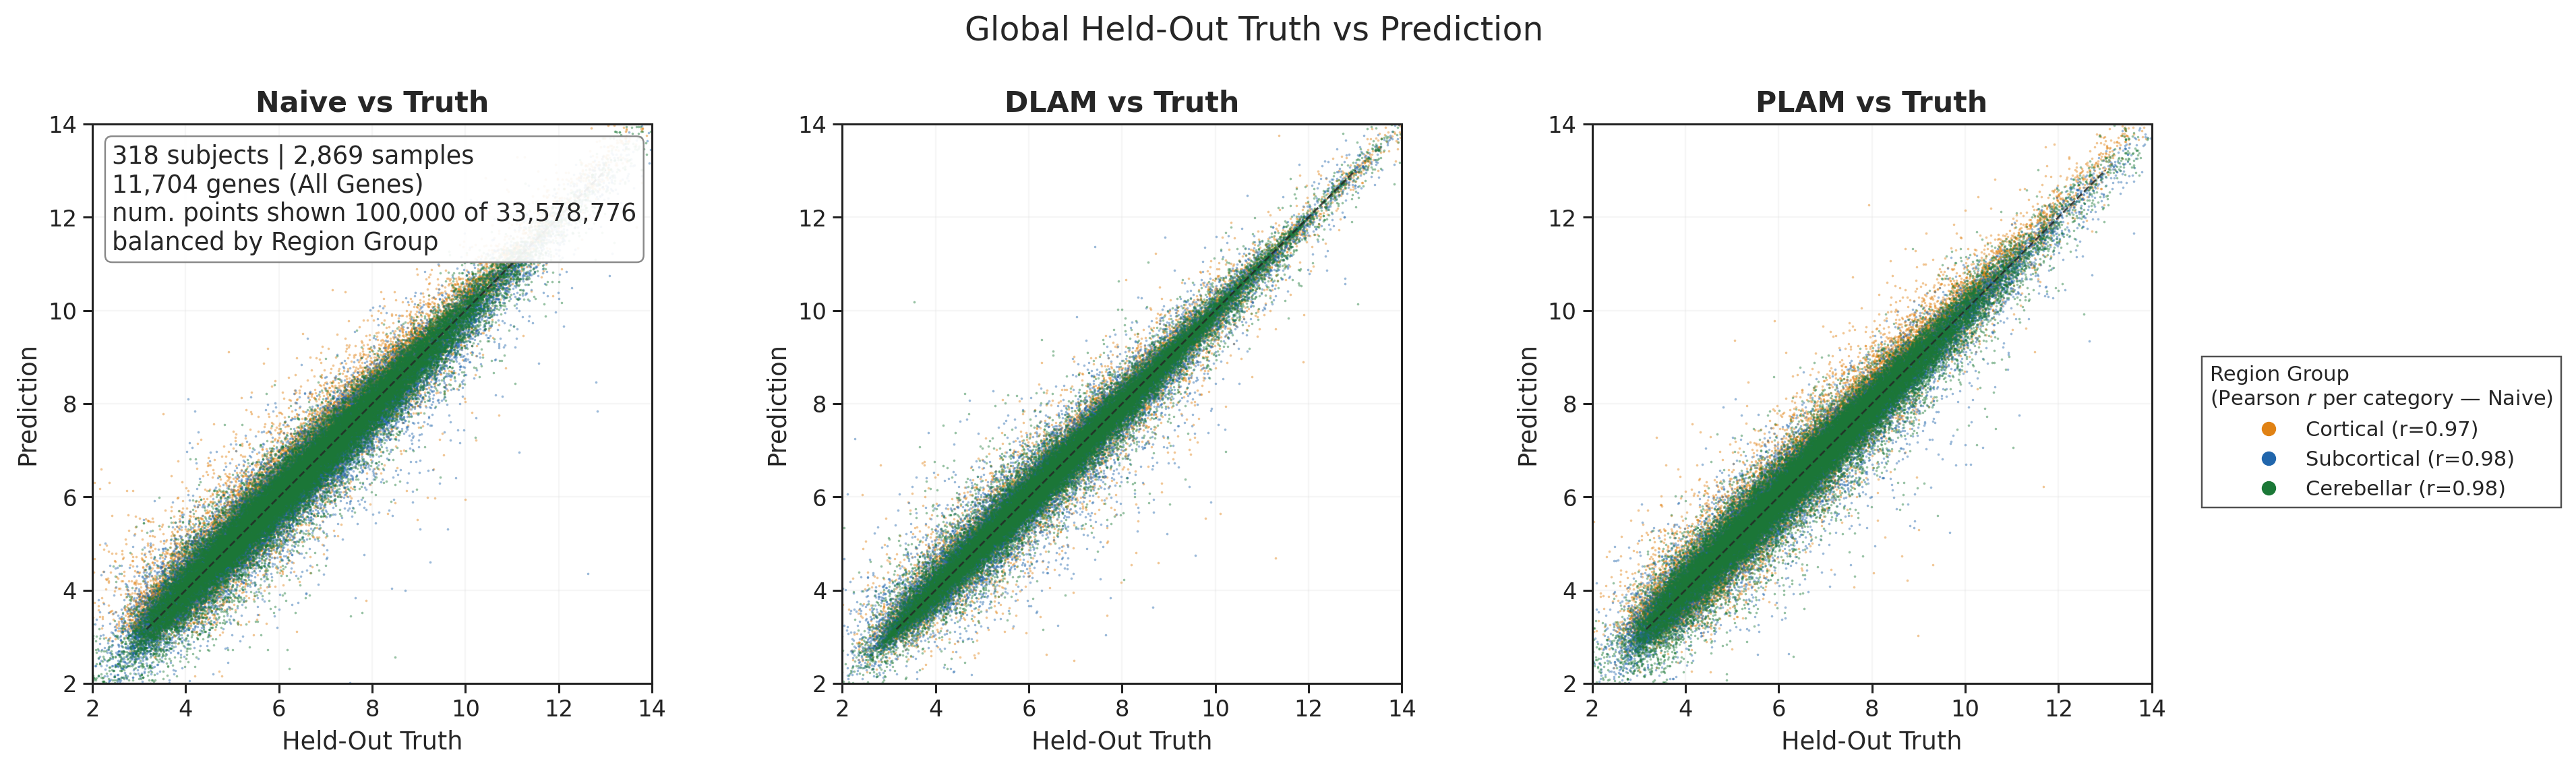

In [7]:
sandbox_view = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    models=MODELS,
    **VIEW_SUBSET,
)

fig, axes = plot_global_prediction_scatter(
    sandbox_view,
    color_by=SANDBOX_COLOR_BY,
    top_n=SANDBOX_TOP_N,
    **SANDBOX_KWS,
)


## Sample-Wise Performance — Global, Sex, and Age


In [8]:
strat_view = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    models=MODELS,
    **VIEW_SUBSET,
)


### Global

No stratification. Per-panel scatter shows global per-model `R` (or chosen metric); the box
plot summarizes per-sample distributions across the three models.


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_population.py:3740: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_population.py:3767: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([model_label(t.get_text()) for t in ax.get_xticklabels()])


model          Naive                                         DLAM  \
metric     pearson_r           r2         rmse     n    pearson_r   
stratum                                                             
global   0.980±0.010  0.951±0.030  0.414±0.113  2869  0.986±0.008   

model                                           PLAM               \
metric            r2         rmse     n    pearson_r           r2   
stratum                                                             
global   0.968±0.021  0.330±0.103  2869  0.983±0.007  0.958±0.020   

model                       
metric          rmse     n  
stratum                     
global   0.386±0.085  2869

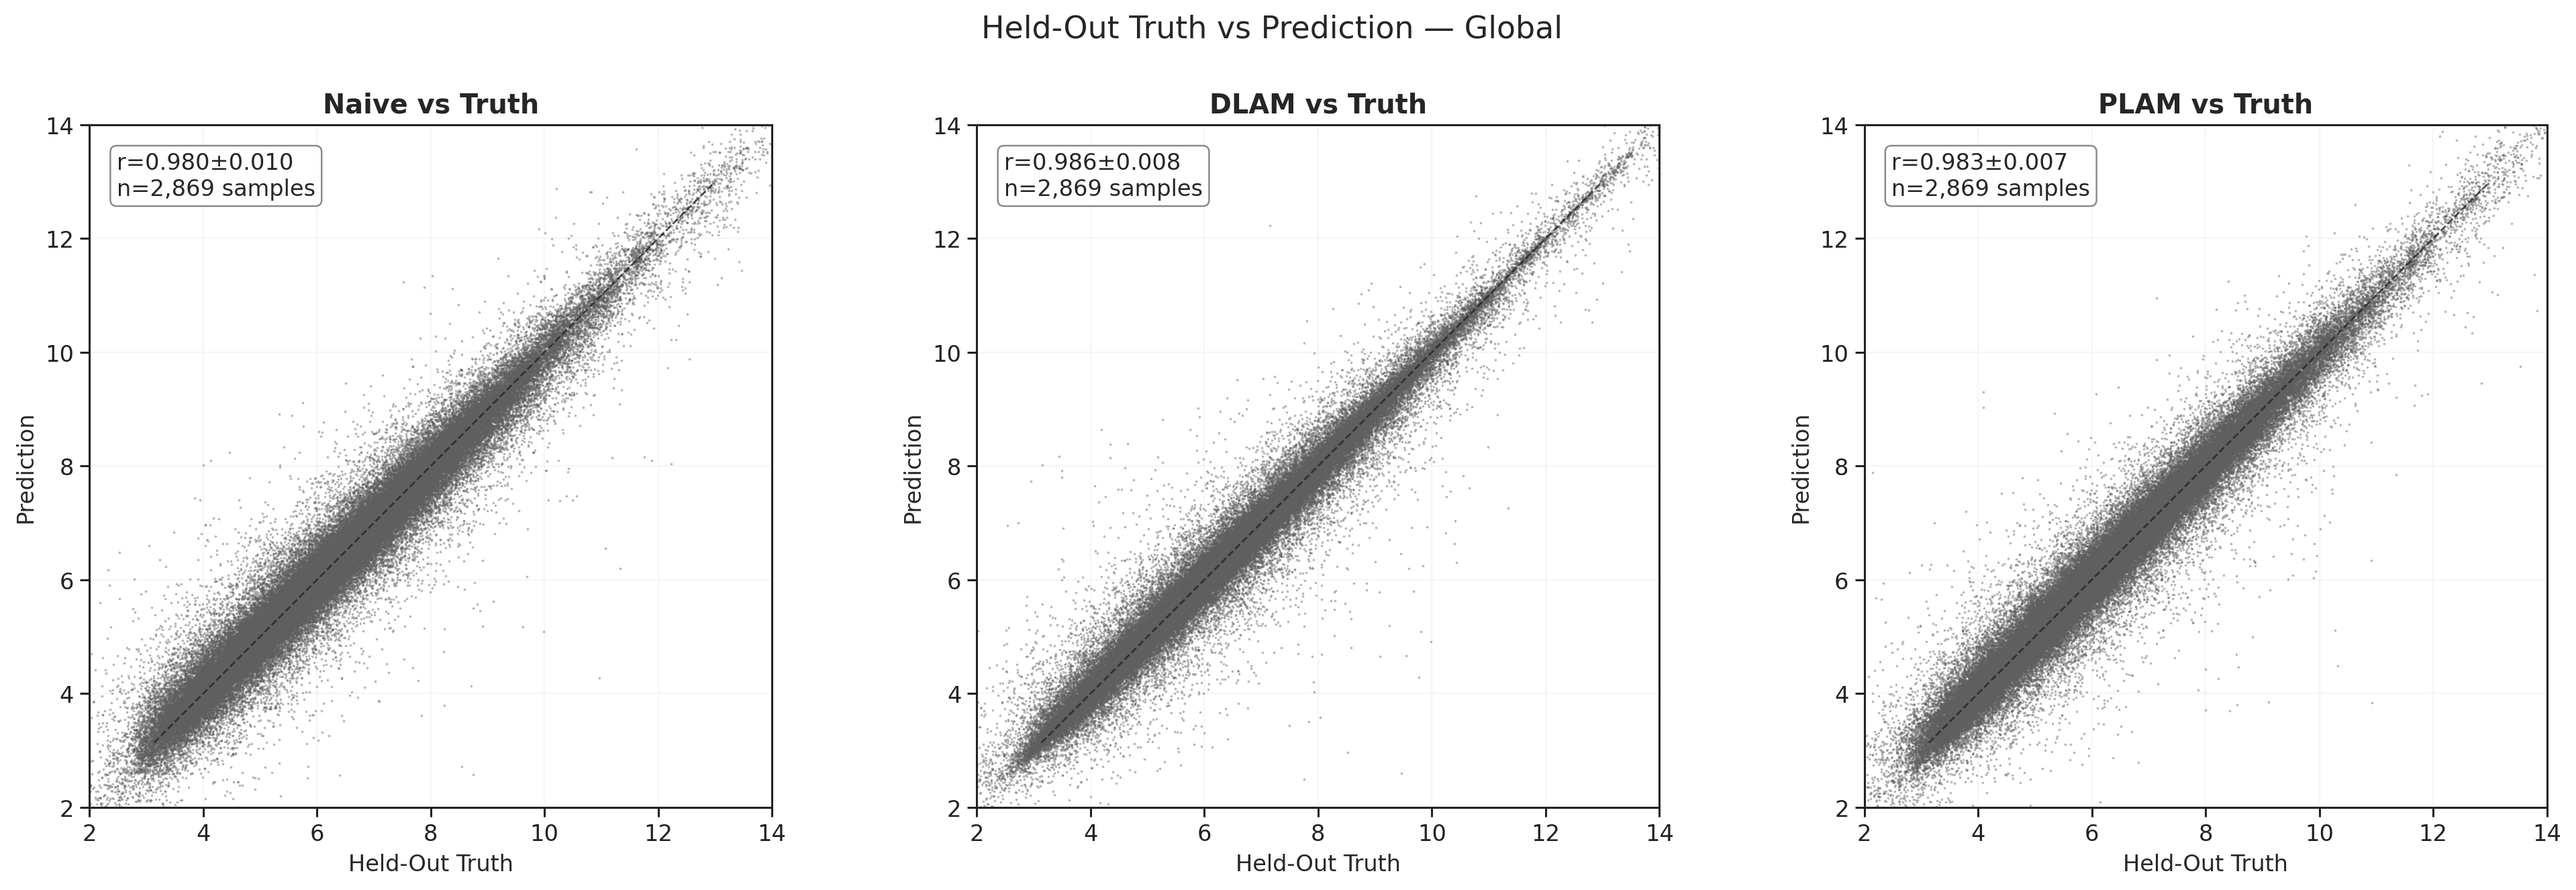

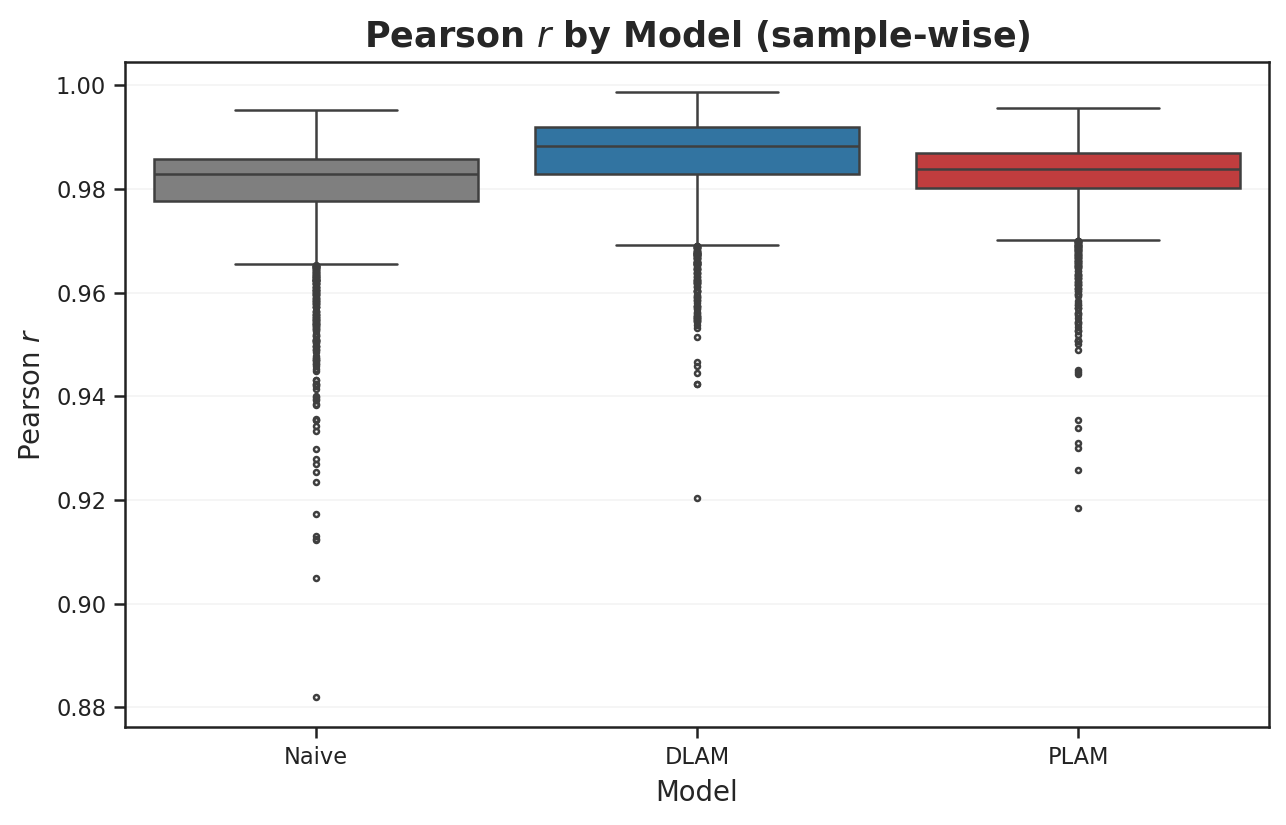

In [9]:
global_metrics, global_summary = compute_prediction_metrics(
    strat_view, unit='sample', stratify_by=None,
    metrics=TABLE_METRICS, n_jobs=N_JOBS,
)

fig, axes, _ = plot_stratified_scatter(
    strat_view, stratify_by=None,
    default_metric=DEFAULT_METRIC,
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    metric_summary=global_summary,
)

fig, ax = plot_stratified_distribution(
    global_metrics, stratify_by=None,
    metric=DEFAULT_METRIC, kind=DISTRIBUTION_KIND,
)

global_table = format_stratified_metric_table(
    global_metrics, stratify_by=None, metrics=TABLE_METRICS,
)
display(global_table)


/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_population.py:3740: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_population.py:3767: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([model_label(t.get_text()) for t in ax.get_xticklabels()])


model          Naive                                         DLAM  \
metric     pearson_r           r2         rmse     n    pearson_r   
stratum                                                             
global   0.980±0.010  0.951±0.030  0.414±0.113  2869  0.986±0.008   

model                                           PLAM               \
metric            r2         rmse     n    pearson_r           r2   
stratum                                                             
global   0.968±0.021  0.330±0.103  2869  0.983±0.007  0.958±0.020   

model                       
metric          rmse     n  
stratum                     
global   0.386±0.085  2869

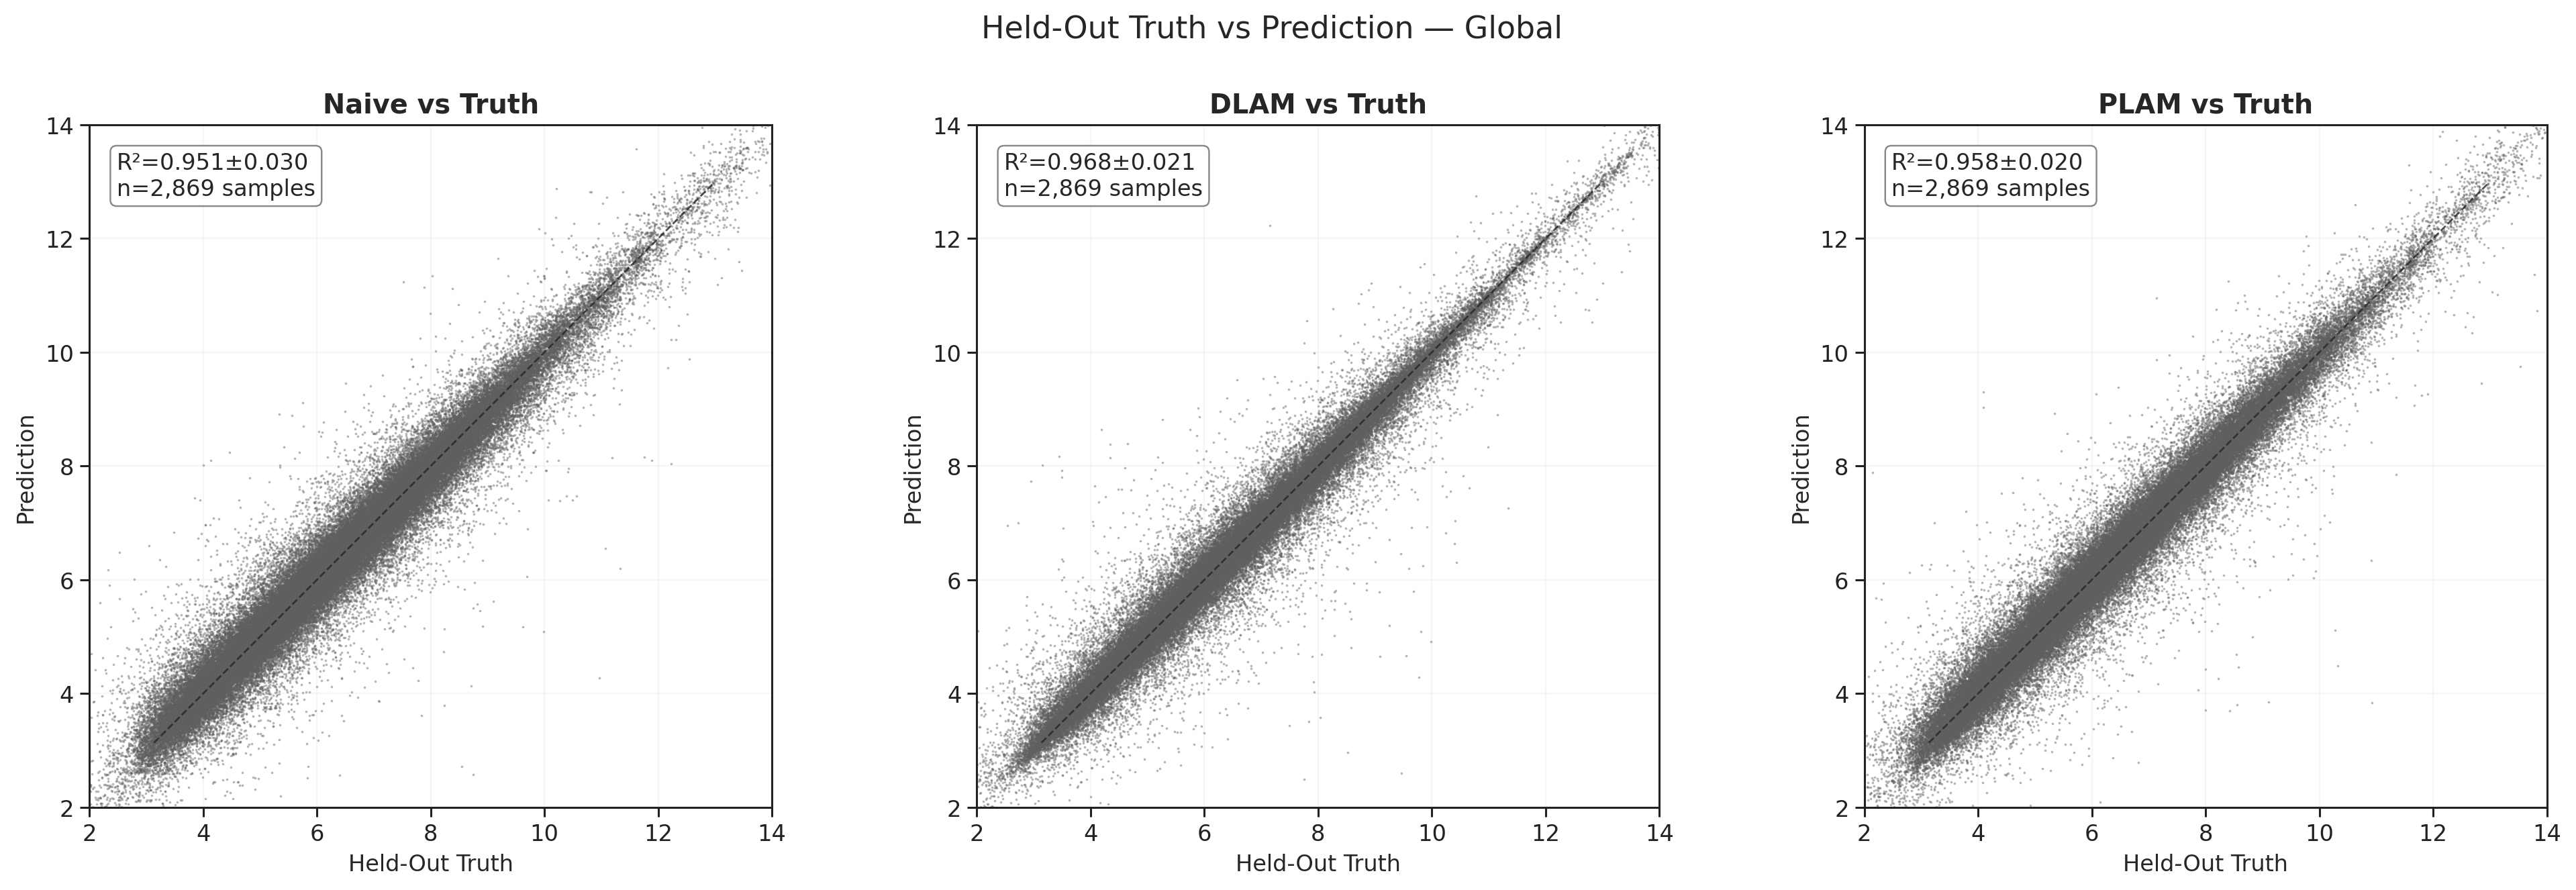

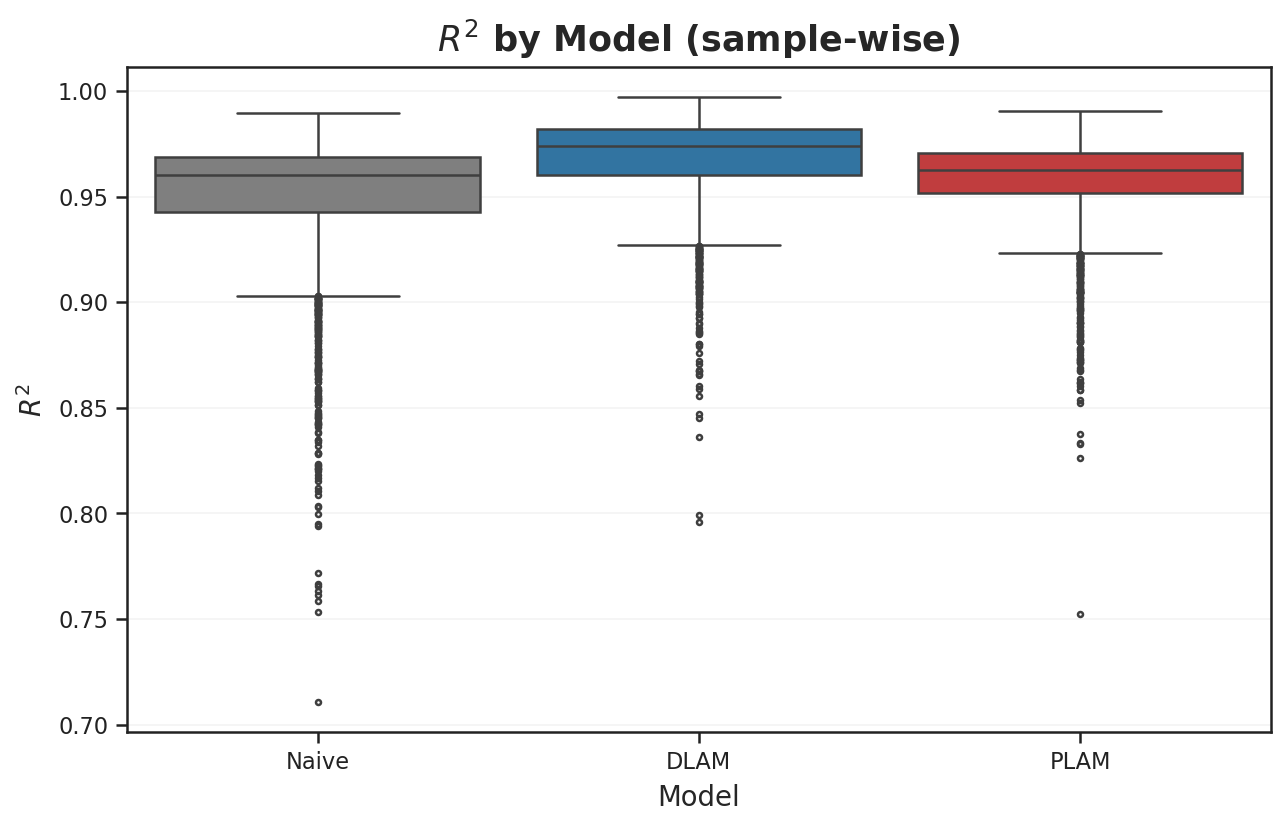

In [10]:
fig, axes, _ = plot_stratified_scatter(
    strat_view, stratify_by=None,
    default_metric='r2',
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    metric_summary=global_summary,
)

fig, ax = plot_stratified_distribution(
    global_metrics, stratify_by=None,
    metric='r2', kind=DISTRIBUTION_KIND,
)

global_table = format_stratified_metric_table(
    global_metrics, stratify_by=None, metrics=TABLE_METRICS,
)
display(global_table)


### Stratified by Sex

When `SHOW_BIAS_FOREST=True`, a forest panel below the box plot reports the LMM-adjusted
contrast (Δ Pearson r vs reference category) for each model after controlling for
age, subject coverage, and `gtex_region`. Subject is a random intercept (each subject
contributes up to 13 region samples). Outcome is Fisher-z transformed for stable
inference and back-transformed for display. p-values FDR-corrected (BH) across all
non-reference contrasts.


model         Naive                                         DLAM               \
metric    pearson_r           r2         rmse     n    pearson_r           r2   
sex                                                                             
F       0.979±0.011  0.947±0.034  0.427±0.123   729  0.986±0.008  0.968±0.020   
M       0.981±0.009  0.952±0.028  0.409±0.109  2140  0.986±0.008  0.968±0.022   

model                             PLAM                                  
metric         rmse     n    pearson_r           r2         rmse     n  
sex                                                                     
F       0.330±0.100   729  0.982±0.007  0.958±0.020  0.388±0.085   729  
M       0.330±0.104  2140  0.983±0.007  0.959±0.020  0.385±0.085  2140

/ext3/miniforge3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/ipykernel_2791160/3349387319.py:31: RuntimeWarning: compute_stratum_bias: LMM fit failed for model='naive' (LinAlgError: Singular matrix); falling back to OLS + cluster-robust SEs.
  sex_bias = compute_stratum_bias(
/ext3/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/ext3/miniforge3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/tmp/ipykernel_2791160/3349387319.py:31: RuntimeWarning: compute_stratum_bias: LMM fit failed for model='

,model,category,is_reference,n,adj_mean,adj_mean_ci_lo,adj_mean_ci_hi,delta_vs_ref,delta_ci_lo,delta_ci_hi,p_raw,p_fdr,method
0,naive,F,True,729,0.980914,0.980101,0.981694,NaN,NaN,NaN,NaN,NaN,ols_cluster
1,naive,M,False,2140,0.982581,0.982131,0.983020,0.001667,0.000794,0.002499,0.000248,0.000745,ols_cluster
3,dlam,F,True,729,0.988310,0.987739,0.988855,NaN,NaN,NaN,NaN,NaN,ols_cluster
4,dlam,M,False,2140,0.988327,0.987965,0.988678,0.000017,-0.000668,0.000663,0.960693,0.960693,ols_cluster
6,plam,F,True,729,0.983729,0.983316,0.984133,NaN,NaN,NaN,NaN,NaN,ols_cluster
7,plam,M,False,2140,0.983910,0.983647,0.984168,0.000180,-0.000311,0.000657,0.468107,0.702161,ols_cluster


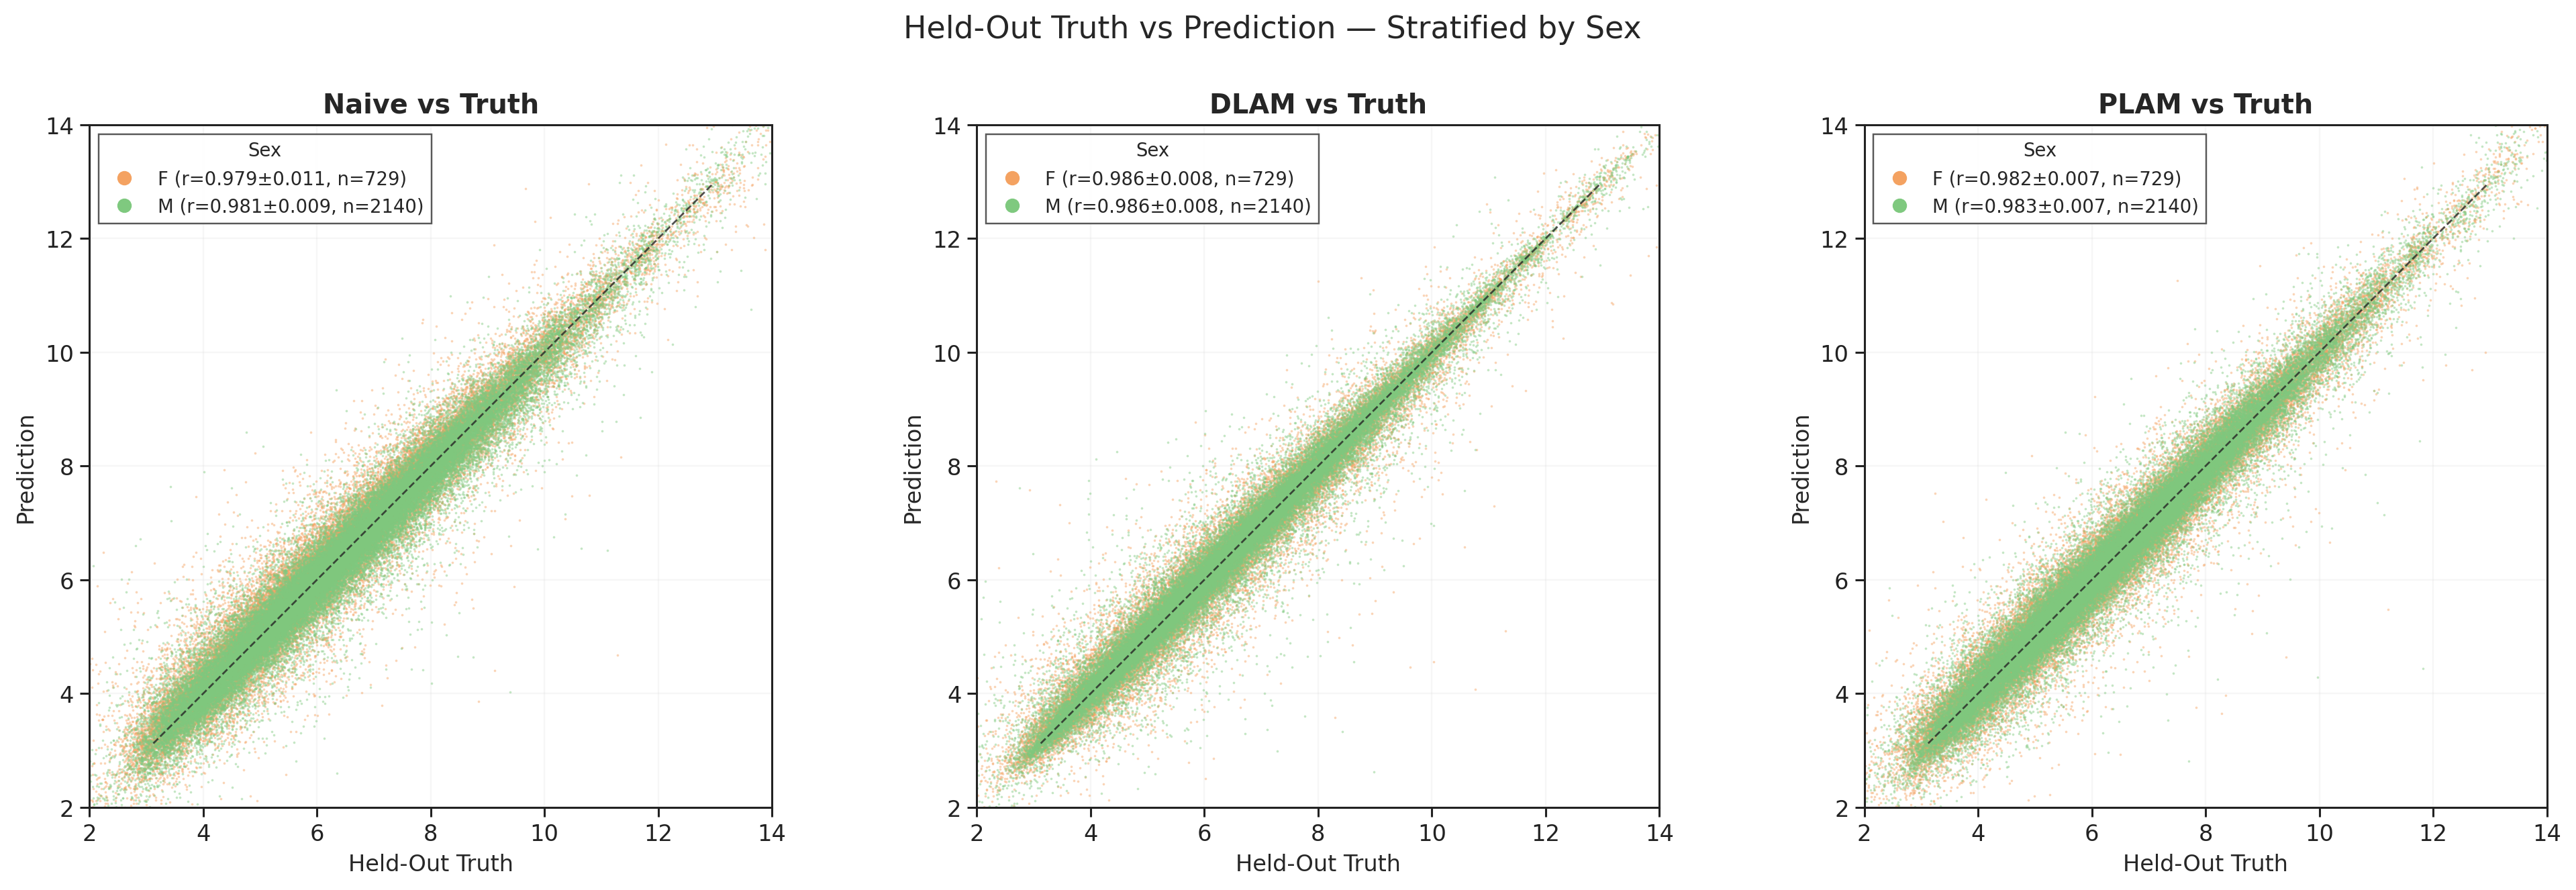

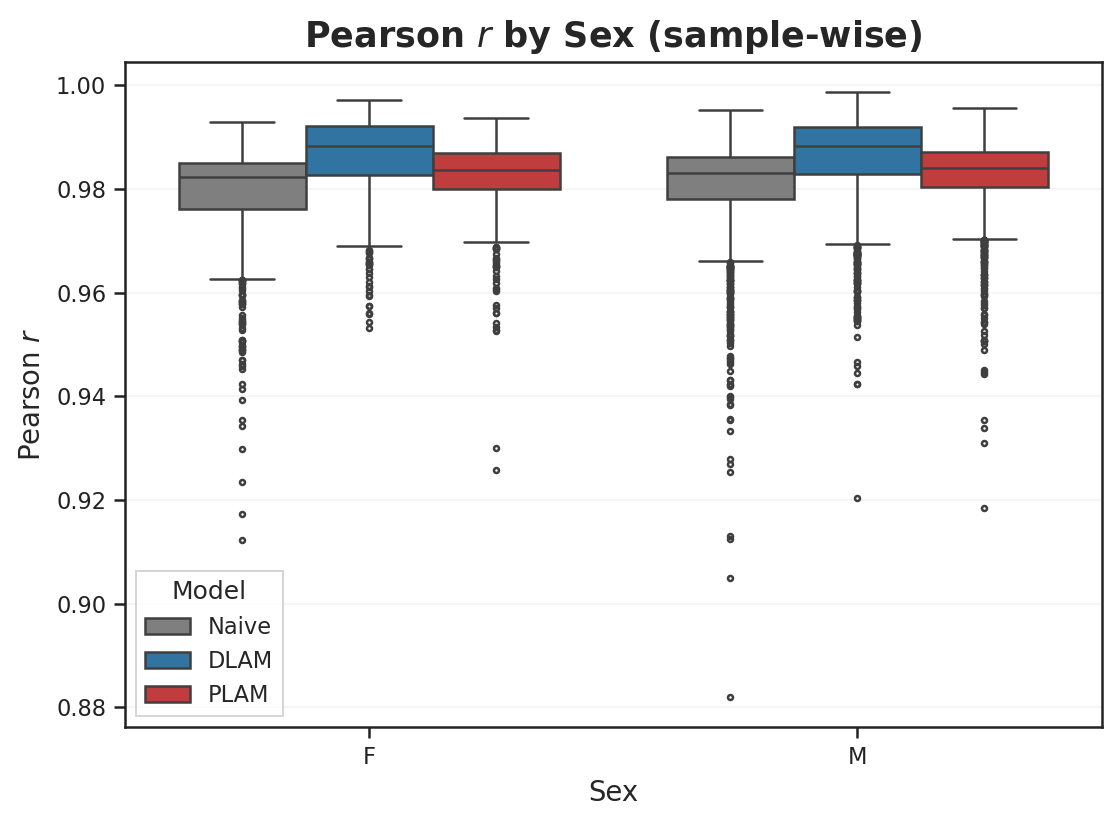

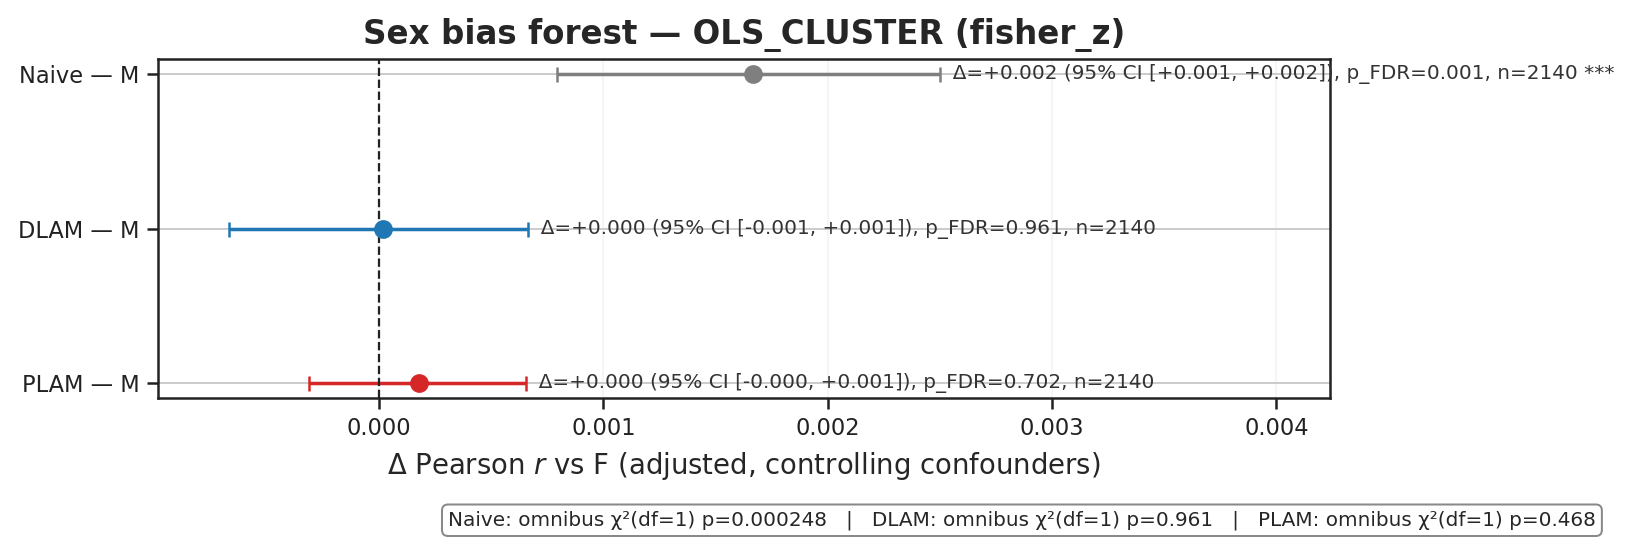

In [11]:

# --- Sex bias forest (LMM with subject random intercept; controls for age, coverage, region) ---
SHOW_BIAS_FOREST             = True
BIAS_METHOD                  = 'lmm'        # 'lmm' | 'ols_cluster'
BIAS_CONTROLS                = ('age', 'subject_coverage', 'gtex_region')
BIAS_REFERENCE_SEX           = None         # None = first level alphabetically

sex_metrics, sex_summary = compute_prediction_metrics(
    strat_view, unit='sample', stratify_by='sex',
    metrics=TABLE_METRICS, n_jobs=N_JOBS,
)

fig, axes, _ = plot_stratified_scatter(
    strat_view, stratify_by='sex',
    default_metric=DEFAULT_METRIC,
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    metric_summary=sex_summary,
)

fig, ax = plot_stratified_distribution(
    sex_metrics, stratify_by='sex',
    metric=DEFAULT_METRIC, kind=DISTRIBUTION_KIND,
)

sex_table = format_stratified_metric_table(
    sex_metrics, stratify_by='sex', metrics=TABLE_METRICS,
)
display(sex_table)

if SHOW_BIAS_FOREST:
    sex_bias = compute_stratum_bias(
        sex_metrics,
        axis='sex',
        models=MODELS,
        metric=DEFAULT_METRIC,
        controls=BIAS_CONTROLS,
        method=BIAS_METHOD,
        reference_category=BIAS_REFERENCE_SEX,
    )
    display(sex_bias[sex_bias['category'] != '__omnibus__'][[
        'model','category','is_reference','n','adj_mean','adj_mean_ci_lo','adj_mean_ci_hi',
        'delta_vs_ref','delta_ci_lo','delta_ci_hi','p_raw','p_fdr','method',
    ]])
    fig_b, ax_b = plot_stratum_bias_forest(sex_bias)


### Stratified by Age (Decade)


model         Naive                                         DLAM               \
metric    pearson_r           r2         rmse     n    pearson_r           r2   
age                                                                             
24.0    0.980±0.009  0.952±0.027  0.412±0.102    68  0.985±0.010  0.966±0.025   
34.0    0.980±0.011  0.952±0.026  0.413±0.103    92  0.985±0.008  0.967±0.018   
44.0    0.980±0.010  0.949±0.034  0.419±0.120   264  0.986±0.008  0.968±0.022   
54.0    0.981±0.009  0.951±0.030  0.412±0.114   869  0.986±0.009  0.968±0.023   
64.0    0.980±0.010  0.951±0.030  0.415±0.114  1441  0.986±0.008  0.968±0.020   
74.0    0.981±0.007  0.952±0.022  0.412±0.090   135  0.987±0.008  0.969±0.022   

model                             PLAM                                  
metric         rmse     n    pearson_r           r2         rmse     n  
age                                                                     
24.0    0.341±0.114    68  0.981±0.007  0.953±0.023  0.412±0.088    68  
34.0    0.338±0.091    92  0.982±0.009  0.956±0.022  0.395±0.089    92  
44.0    0.328±0.105   264  0.982±0.007  0.958±0.020  0.387±0.085   264  
54.0    0.329±0.109   869  0.983±0.007  0.959±0.022  0.384±0.089   869  
64.0    0.331±0.098  1441  0.983±0.007  0.958±0.019  0.385±0.083  1441  
74.0    0.324±0.108   135  0.983±0.006  0.960±0.018  0.377±0.078   135

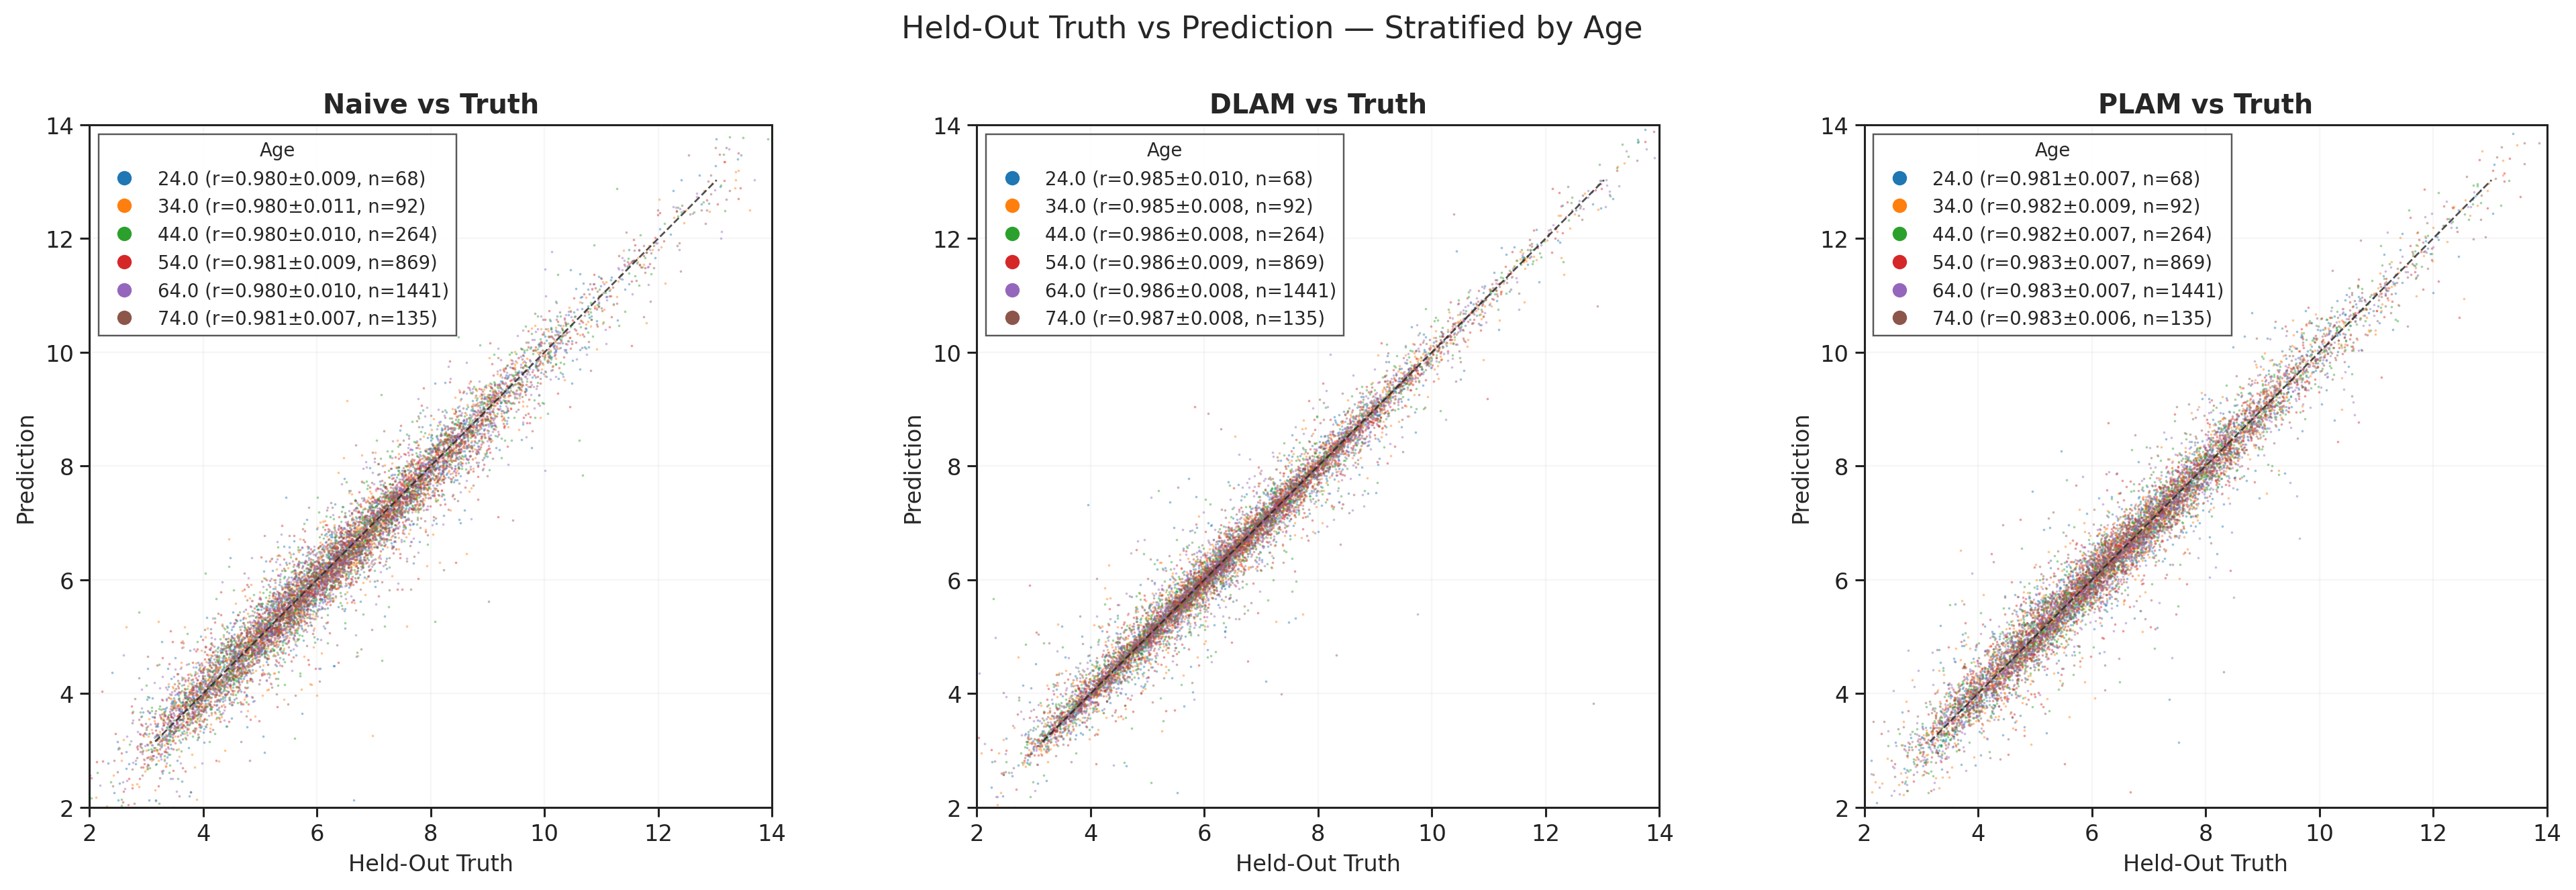

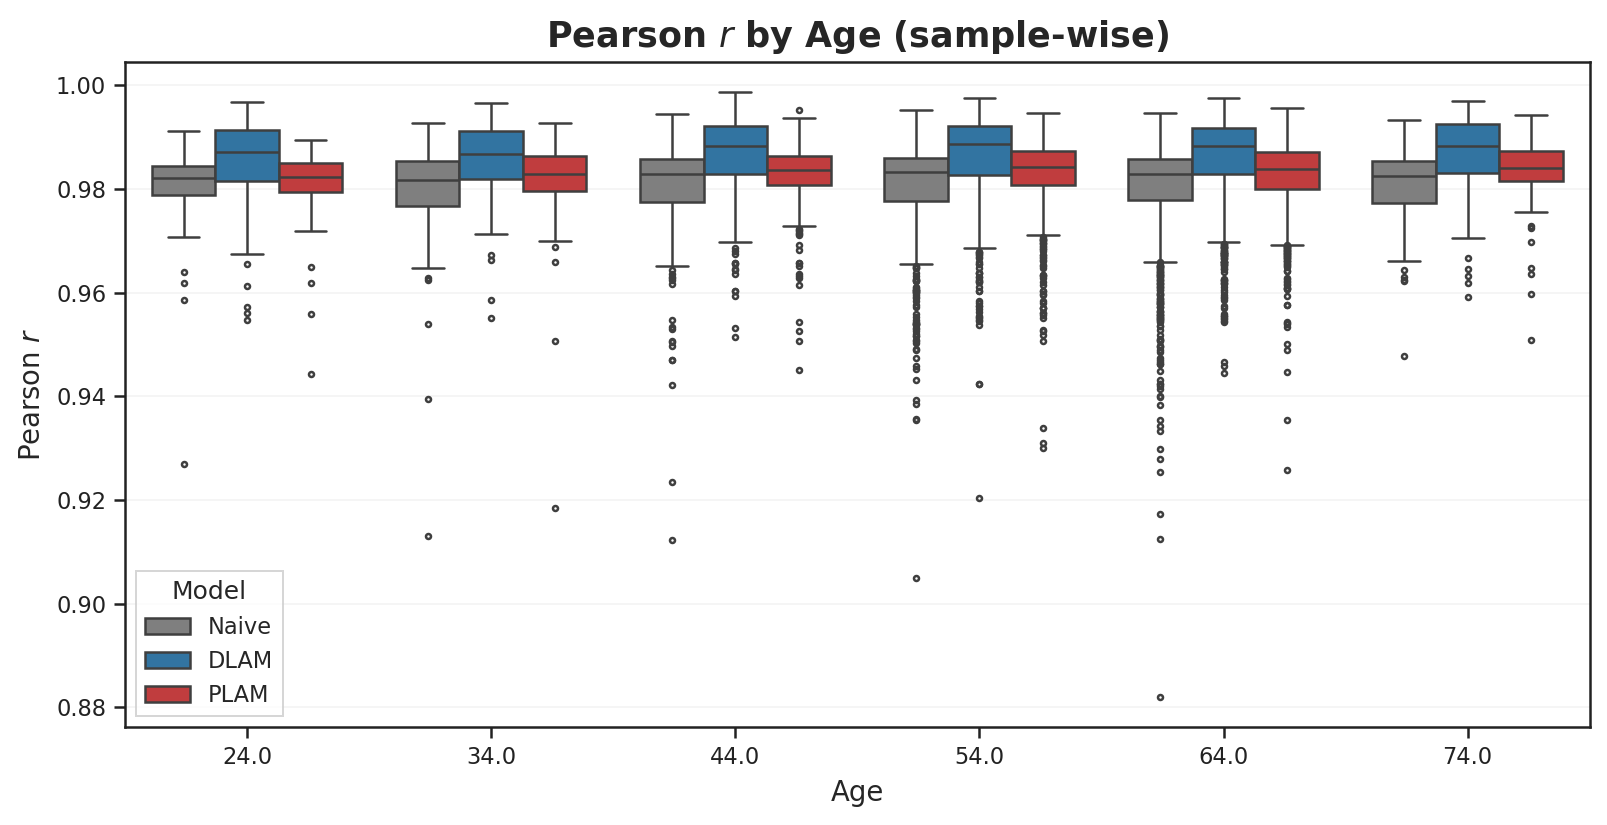

In [12]:
age_metrics, age_summary = compute_prediction_metrics(
    strat_view, unit='sample', stratify_by='age',
    metrics=TABLE_METRICS, n_jobs=N_JOBS,
)

fig, axes, _ = plot_stratified_scatter(
    strat_view, stratify_by='age',
    default_metric=DEFAULT_METRIC,
    max_points_per_model=10_000,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    metric_summary=age_summary,
)

fig, ax = plot_stratified_distribution(
    age_metrics, stratify_by='age',
    metric=DEFAULT_METRIC, kind=DISTRIBUTION_KIND,
)

age_table = format_stratified_metric_table(
    age_metrics, stratify_by='age', metrics=TABLE_METRICS,
)
display(age_table)


model         Naive                                         DLAM               \
metric    pearson_r           r2         rmse     n    pearson_r           r2   
age                                                                             
24.0    0.980±0.009  0.952±0.027  0.412±0.102    68  0.985±0.010  0.966±0.025   
34.0    0.980±0.011  0.952±0.026  0.413±0.103    92  0.985±0.008  0.967±0.018   
44.0    0.980±0.010  0.949±0.034  0.419±0.120   264  0.986±0.008  0.968±0.022   
54.0    0.981±0.009  0.951±0.030  0.412±0.114   869  0.986±0.009  0.968±0.023   
64.0    0.980±0.010  0.951±0.030  0.415±0.114  1441  0.986±0.008  0.968±0.020   
74.0    0.981±0.007  0.952±0.022  0.412±0.090   135  0.987±0.008  0.969±0.022   

model                             PLAM                                  
metric         rmse     n    pearson_r           r2         rmse     n  
age                                                                     
24.0    0.341±0.114    68  0.981±0.007  0.953±0.023  0.412±0.088    68  
34.0    0.338±0.091    92  0.982±0.009  0.956±0.022  0.395±0.089    92  
44.0    0.328±0.105   264  0.982±0.007  0.958±0.020  0.387±0.085   264  
54.0    0.329±0.109   869  0.983±0.007  0.959±0.022  0.384±0.089   869  
64.0    0.331±0.098  1441  0.983±0.007  0.958±0.019  0.385±0.083  1441  
74.0    0.324±0.108   135  0.983±0.006  0.960±0.018  0.377±0.078   135

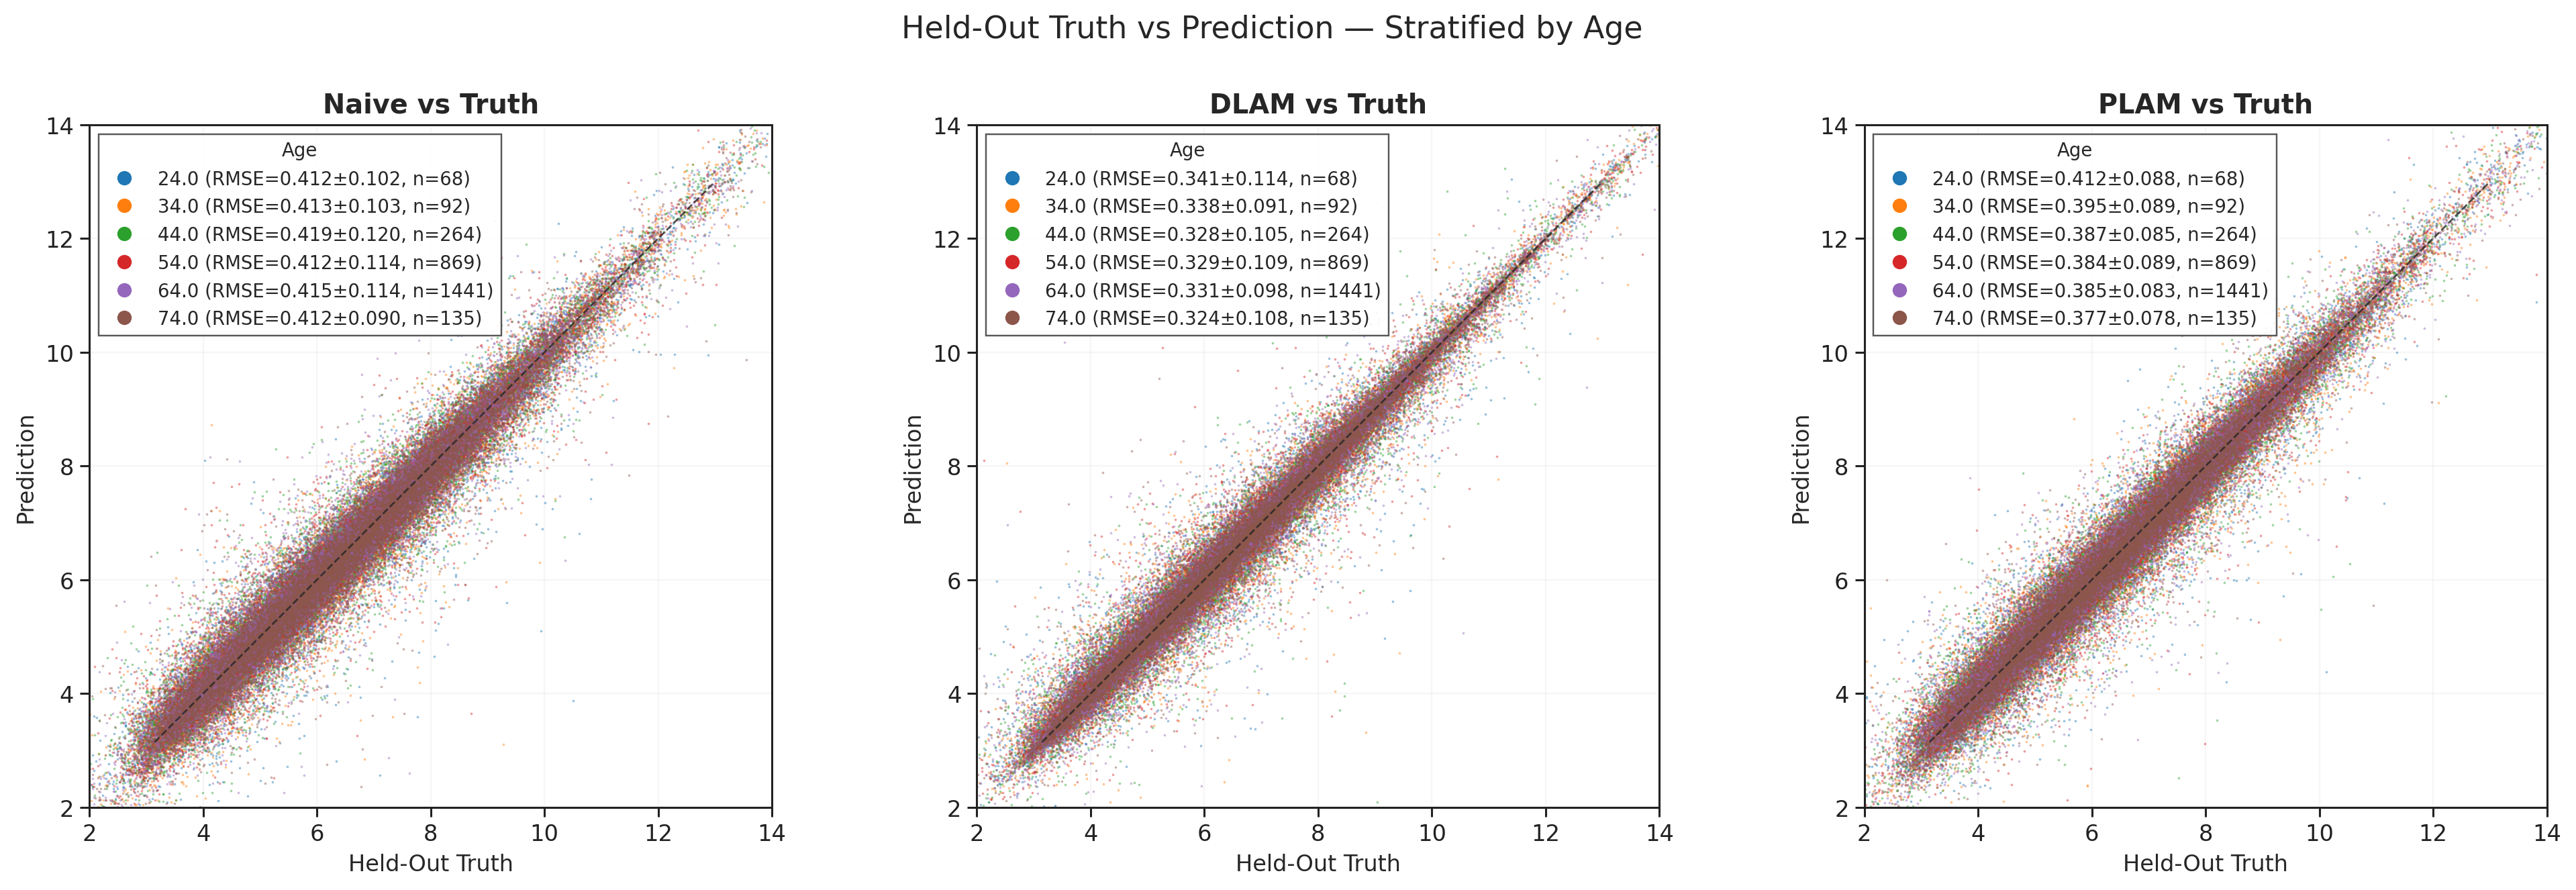

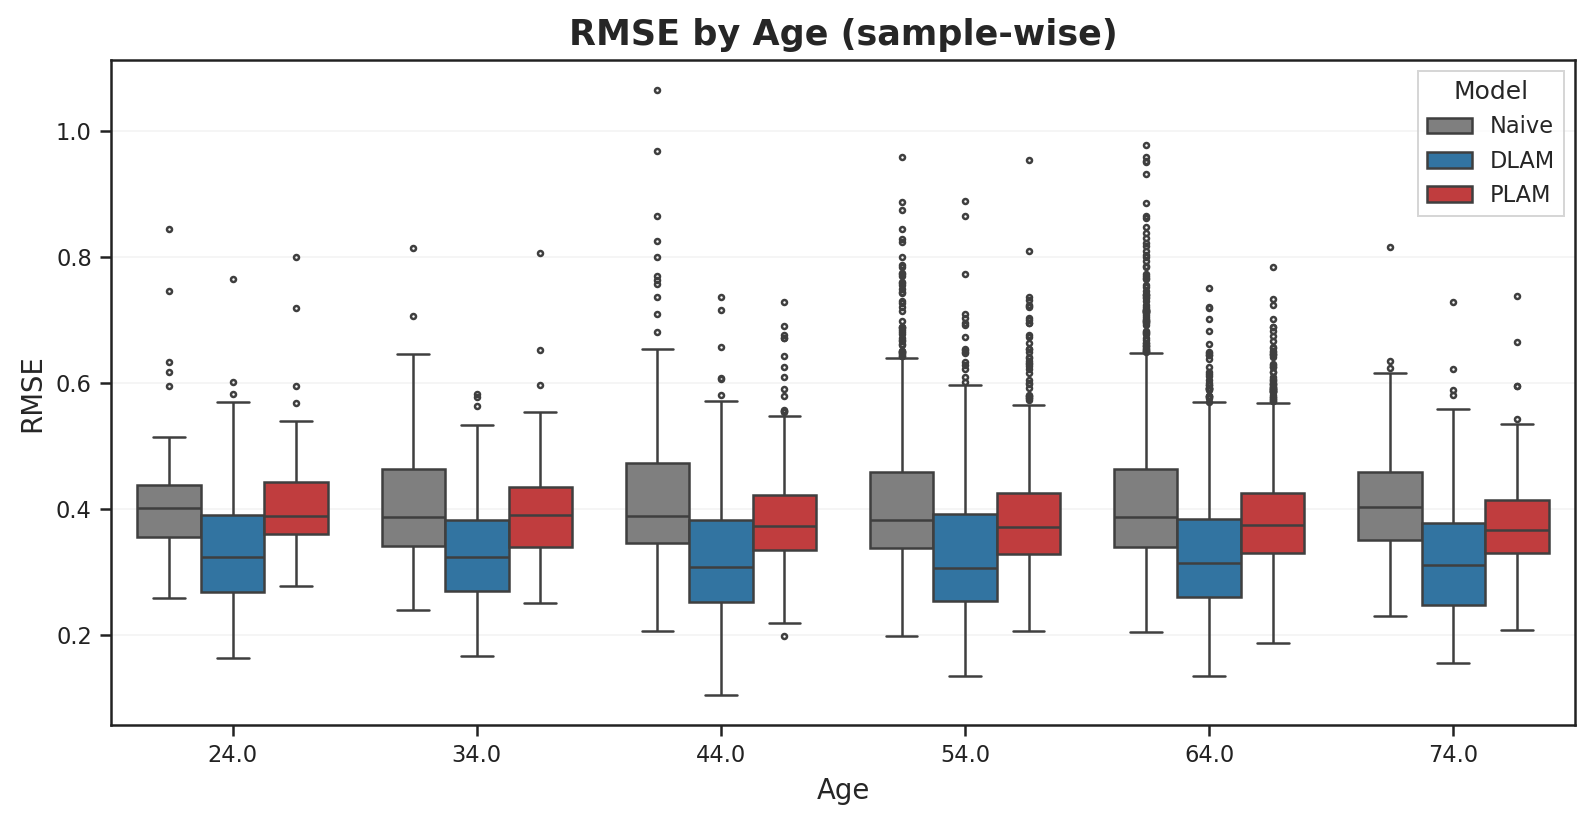

In [13]:
age_metrics, age_summary = compute_prediction_metrics(
    strat_view, unit='sample', stratify_by='age',
    metrics=TABLE_METRICS, n_jobs=N_JOBS,
)

fig, axes, _ = plot_stratified_scatter(
    strat_view, stratify_by='age',
    default_metric='rmse',
    max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
    balanced_sampling=SCATTER_BALANCED_SAMPLING,
    metric_summary=age_summary,
)

fig, ax = plot_stratified_distribution(
    age_metrics, stratify_by='age',
    metric='rmse', kind=DISTRIBUTION_KIND,
)

age_table = format_stratified_metric_table(
    age_metrics, stratify_by='age', metrics=TABLE_METRICS,
)
display(age_table)


## Regional analyses

Region-stratified summaries and region fan plots now live in `eval_regional.ipynb`.


## Coverage, Combos, and Distance Effects

Sample-wise metric per subject vs the number of observed GTEx regions for that subject. Uses
`global_metrics` from the global stratification section above.


In [14]:
# --- LORO fold-combo (end of notebook) ---
FOLD_COMBO_COVERAGE_MIN      = 5
FOLD_COMBO_COVERAGE_MAX      = 12
FOLD_COMBO_METRIC            = 'mean_pearson'   # mean_pearson | mean_spearman | mean_r2 | mean_rmse
FOLD_COMBO_REFERENCE_MODEL   = 'plam'
# 'line' (default) | 'dist_to_nearest_train' | 'dist_to_centroid_train'
FOLD_COMBO_POINTS_STYLE      = 'dist_to_nearest_train'

# --- Distance-to-training plot ---
DISTANCE_COL                 = 'dist_to_nearest_train'  # or 'dist_to_nearest_train'
DISTANCE_N_BINS              = 20

,subject,model,subject_coverage,pearson_r
0,GTEX-1117F,dlam,9,0.988485
1,GTEX-1117F,naive,9,0.980898
2,GTEX-1117F,plam,9,0.984830
3,GTEX-111FC,dlam,11,0.987670
4,GTEX-111FC,naive,11,0.981943


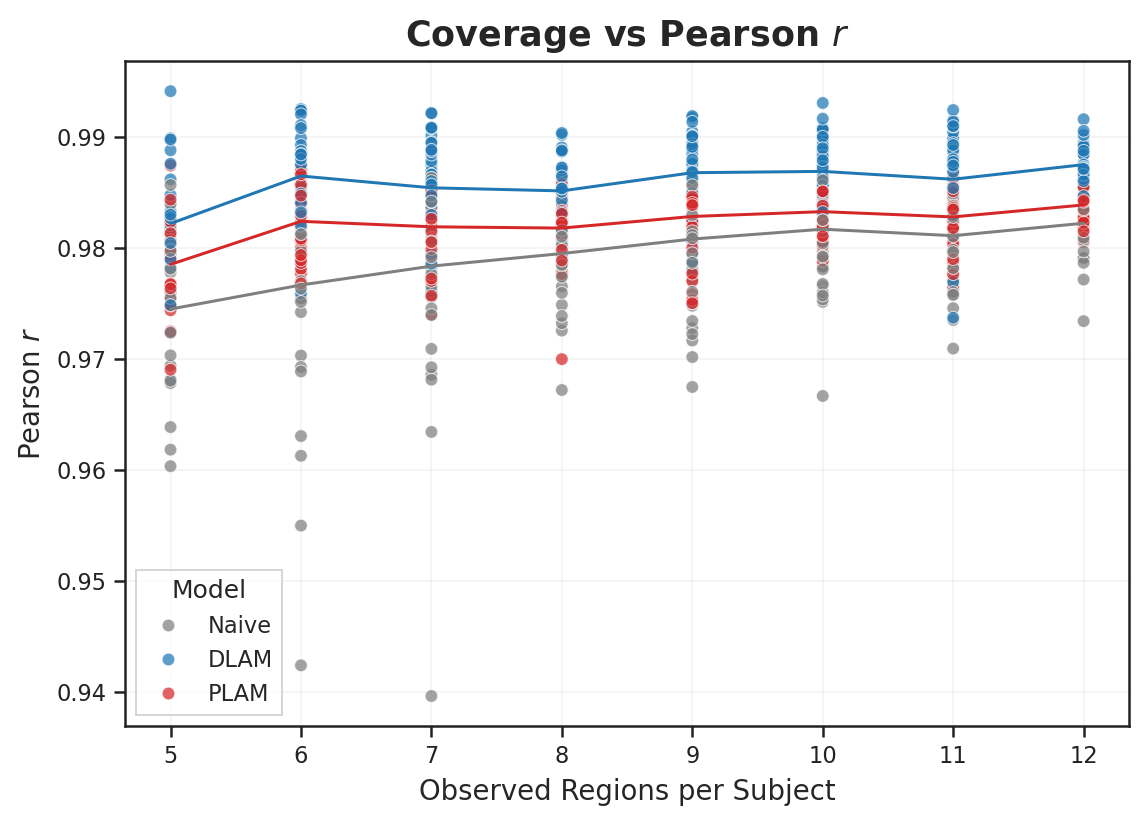

In [15]:
fig, ax, coverage_plot_df = plot_coverage_vs_metric(
    global_metrics,
    metric=DEFAULT_METRIC,
)
display(coverage_plot_df.head())


## LORO Fold-Combo Curves

Fold-combo summaries rank held-out region sets from worst to best performance per model.
Set `FOLD_COMBO_POINTS_STYLE='line'` for connected lines colored by `MODEL_COLORS`, or
`'dist_to_nearest_train'` / `'dist_to_centroid_train'` to render the same curves as a
scatter where marker color encodes distance from the held-out region to the training set
(shared colorbar) and marker shape encodes the model.

The matched overlay below ranks every model on the **reference model**'s combo order,
so model curves are directly comparable per fold-combo.


In [16]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG,
    PREPOST,
    coverage_min=FOLD_COMBO_COVERAGE_MIN,
    coverage_max=FOLD_COMBO_COVERAGE_MAX,
    models=MODELS,
    eval_gene_path=EVAL_GENE_LIST_PATH,
    n_jobs=N_JOBS,
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)
display(combo_df.head())


fold_perf_df: (8607, 16)
combo_df: (4509, 17)


,coverage,fold_key,model,n_subjects,mean_pearson,std_pearson,mean_spearman,std_spearman,mean_r2,std_r2,mean_rmse,std_rmse,mean_points,dist_to_nearest_train,dist_to_centroid_train,eval_gene_mode,eval_gene_path
0,5,"hold=10|train=16,18,19,64",dlam,1,0.997400,NaN,0.997306,NaN,0.992697,NaN,0.164387,NaN,11704.0,15.450981,8.804252,all,None
1,5,"hold=10|train=16,18,29,55",dlam,1,0.984958,NaN,0.984147,NaN,0.967410,NaN,0.343143,NaN,11704.0,19.023247,25.504232,all,None
2,5,"hold=10|train=16,18,61,64",dlam,1,0.995257,NaN,0.994711,NaN,0.990347,NaN,0.188384,NaN,11704.0,19.023247,10.493721,all,None
3,5,"hold=10|train=18,19,37,55",dlam,1,0.992671,NaN,0.992241,NaN,0.983355,NaN,0.250003,NaN,11704.0,15.450981,17.402212,all,None
4,5,"hold=10|train=18,19,37,61",dlam,1,0.998695,NaN,0.998588,NaN,0.997074,NaN,0.105187,NaN,11704.0,15.450981,15.915948,all,None


,rank_kind,rank_tag,model,model_label,metric,score,rank_index,rank_percentile,coverage,n_subjects,fold_key,hold_parcel,hold_label,train_parcels,train_labels
0,independent,worst,naive,Naive,mean_pearson,0.882012,0,0.0,7,1,"hold=64|train=10,16,18,23,55,61",64,Frontal cortex (BA9),"[10, 16, 18, 23, 55, 61]","[Caudate (basal ganglia), Hypothalamus, Nucleu..."
1,independent,median,naive,Naive,mean_pearson,0.982197,751,50.0,9,1,"hold=4|train=10,16,18,19,29,37,55,61",4,Cerebellar hemisphere,"[10, 16, 18, 19, 29, 37, 55, 61]","[Caudate (basal ganglia), Hypothalamus, Nucleu..."
2,independent,best,naive,Naive,mean_pearson,0.994298,1502,100.0,9,2,"hold=19|train=4,7,10,18,23,29,37,61",19,Putamen (basal ganglia),"[4, 7, 10, 18, 23, 29, 37, 61]","[Cerebellar hemisphere, Cerebellum, Caudate (b..."
3,independent,worst,dlam,DLAM,mean_pearson,0.942356,0,0.0,10,1,"hold=16|train=4,7,10,18,19,23,29,55,64",16,Hypothalamus,"[4, 7, 10, 18, 19, 23, 29, 55, 64]","[Cerebellar hemisphere, Cerebellum, Caudate (b..."
4,independent,median,dlam,DLAM,mean_pearson,0.987930,751,50.0,8,1,"hold=18|train=4,7,10,23,55,61,64",18,Nucleus accumbens (basal ganglia),"[4, 7, 10, 23, 55, 61, 64]","[Cerebellar hemisphere, Cerebellum, Caudate (b..."
5,independent,best,dlam,DLAM,mean_pearson,0.998695,1502,100.0,5,1,"hold=10|train=18,19,37,61",10,Caudate (basal ganglia),"[18, 19, 37, 61]","[Nucleus accumbens (basal ganglia), Putamen (b..."
6,independent,worst,plam,PLAM,mean_pearson,0.918507,0,0.0,10,1,"hold=64|train=7,10,16,18,19,23,37,55,61",64,Frontal cortex (BA9),"[7, 10, 16, 18, 19, 23, 37, 55, 61]","[Cerebellum, Caudate (basal ganglia), Hypothal..."
7,independent,median,plam,PLAM,mean_pearson,0.983497,751,50.0,10,3,"hold=61|train=4,10,16,18,23,29,37,55,64",61,Anterior cingulate cortex (BA24),"[4, 10, 16, 18, 23, 29, 37, 55, 64]","[Cerebellar hemisphere, Caudate (basal ganglia..."
8,independent,best,plam,PLAM,mean_pearson,0.995675,1502,100.0,6,1,"hold=10|train=16,18,19,29,64",10,Caudate (basal ganglia),"[16, 18, 19, 29, 64]","[Hypothalamus, Nucleus accumbens (basal gangli..."


,rank_kind,rank_tag,model,model_label,metric,score,rank_index,rank_percentile,coverage,n_subjects,fold_key,hold_parcel,hold_label,train_parcels,train_labels
0,matched_to_plam,worst,naive,Naive,mean_pearson,0.913089,0,0.0,10,1,"hold=64|train=7,10,16,18,19,23,37,55,61",64,Frontal cortex (BA9),"[7, 10, 16, 18, 19, 23, 37, 55, 61]","[Cerebellum, Caudate (basal ganglia), Hypothal..."
1,matched_to_plam,median,naive,Naive,mean_pearson,0.976069,751,50.0,10,3,"hold=61|train=4,10,16,18,23,29,37,55,64",61,Anterior cingulate cortex (BA24),"[4, 10, 16, 18, 23, 29, 37, 55, 64]","[Cerebellar hemisphere, Caudate (basal ganglia..."
2,matched_to_plam,best,naive,Naive,mean_pearson,0.982879,1502,100.0,6,1,"hold=10|train=16,18,19,29,64",10,Caudate (basal ganglia),"[16, 18, 19, 29, 64]","[Hypothalamus, Nucleus accumbens (basal gangli..."
3,matched_to_plam,worst,dlam,DLAM,mean_pearson,0.955136,0,0.0,10,1,"hold=64|train=7,10,16,18,19,23,37,55,61",64,Frontal cortex (BA9),"[7, 10, 16, 18, 19, 23, 37, 55, 61]","[Cerebellum, Caudate (basal ganglia), Hypothal..."
4,matched_to_plam,median,dlam,DLAM,mean_pearson,0.988605,751,50.0,10,3,"hold=61|train=4,10,16,18,23,29,37,55,64",61,Anterior cingulate cortex (BA24),"[4, 10, 16, 18, 23, 29, 37, 55, 64]","[Cerebellar hemisphere, Caudate (basal ganglia..."
5,matched_to_plam,best,dlam,DLAM,mean_pearson,0.996796,1502,100.0,6,1,"hold=10|train=16,18,19,29,64",10,Caudate (basal ganglia),"[16, 18, 19, 29, 64]","[Hypothalamus, Nucleus accumbens (basal gangli..."
6,matched_to_plam,worst,plam,PLAM,mean_pearson,0.918507,0,0.0,10,1,"hold=64|train=7,10,16,18,19,23,37,55,61",64,Frontal cortex (BA9),"[7, 10, 16, 18, 19, 23, 37, 55, 61]","[Cerebellum, Caudate (basal ganglia), Hypothal..."
7,matched_to_plam,median,plam,PLAM,mean_pearson,0.983497,751,50.0,10,3,"hold=61|train=4,10,16,18,23,29,37,55,64",61,Anterior cingulate cortex (BA24),"[4, 10, 16, 18, 23, 29, 37, 55, 64]","[Cerebellar hemisphere, Caudate (basal ganglia..."
8,matched_to_plam,best,plam,PLAM,mean_pearson,0.995675,1502,100.0,6,1,"hold=10|train=16,18,19,29,64",10,Caudate (basal ganglia),"[16, 18, 19, 29, 64]","[Hypothalamus, Nucleus accumbens (basal gangli..."


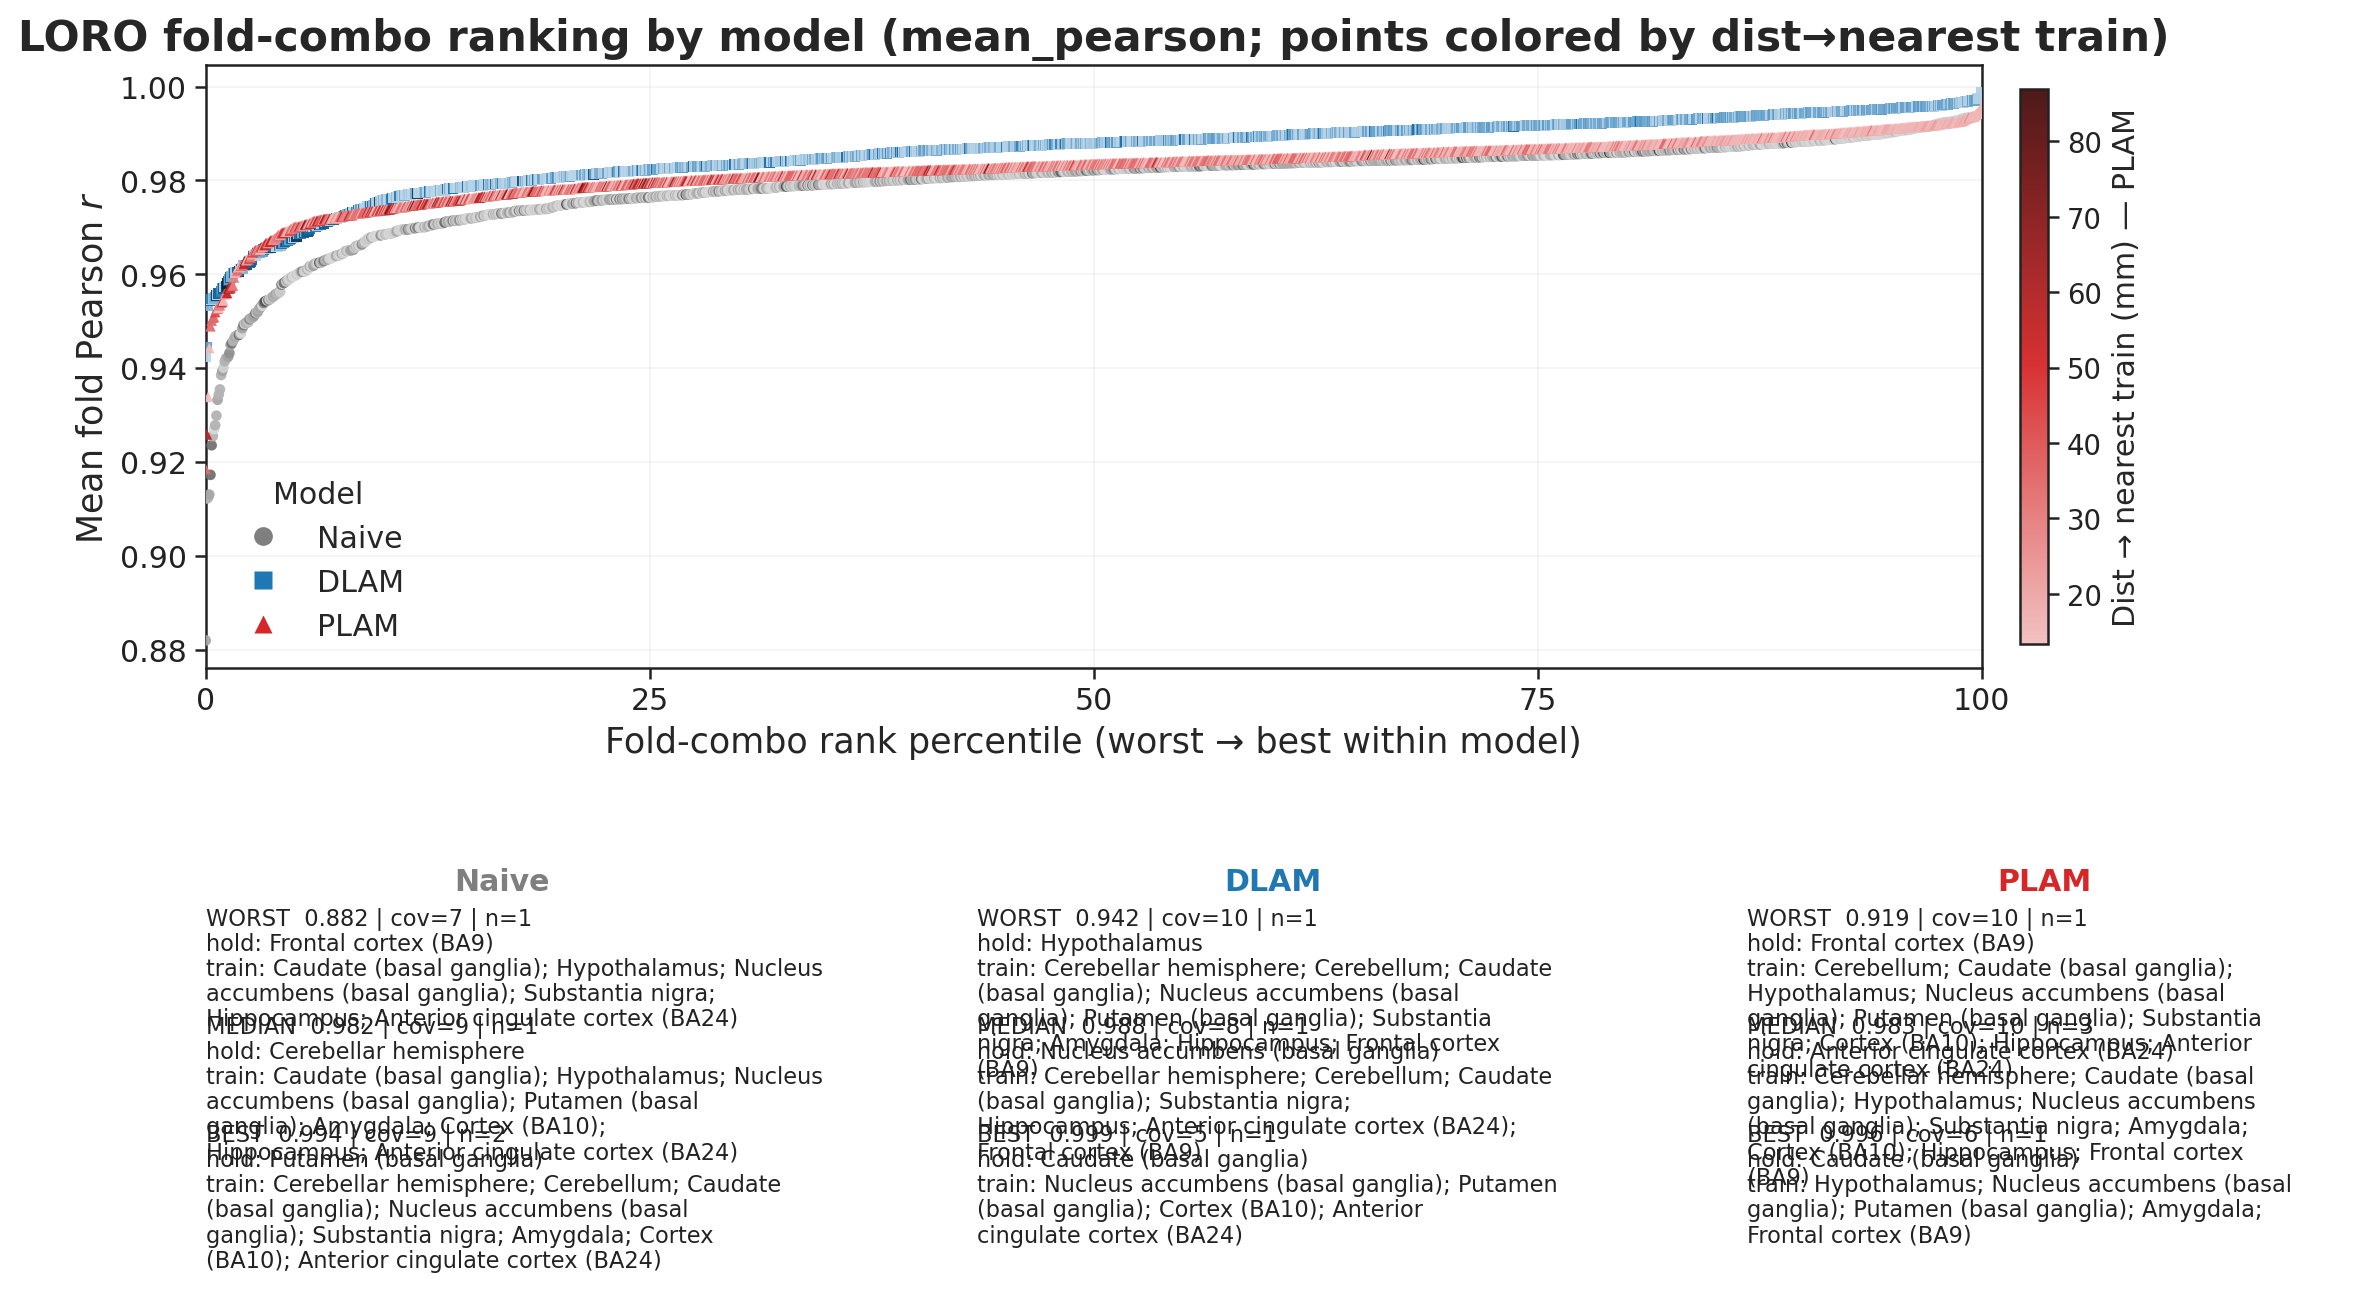

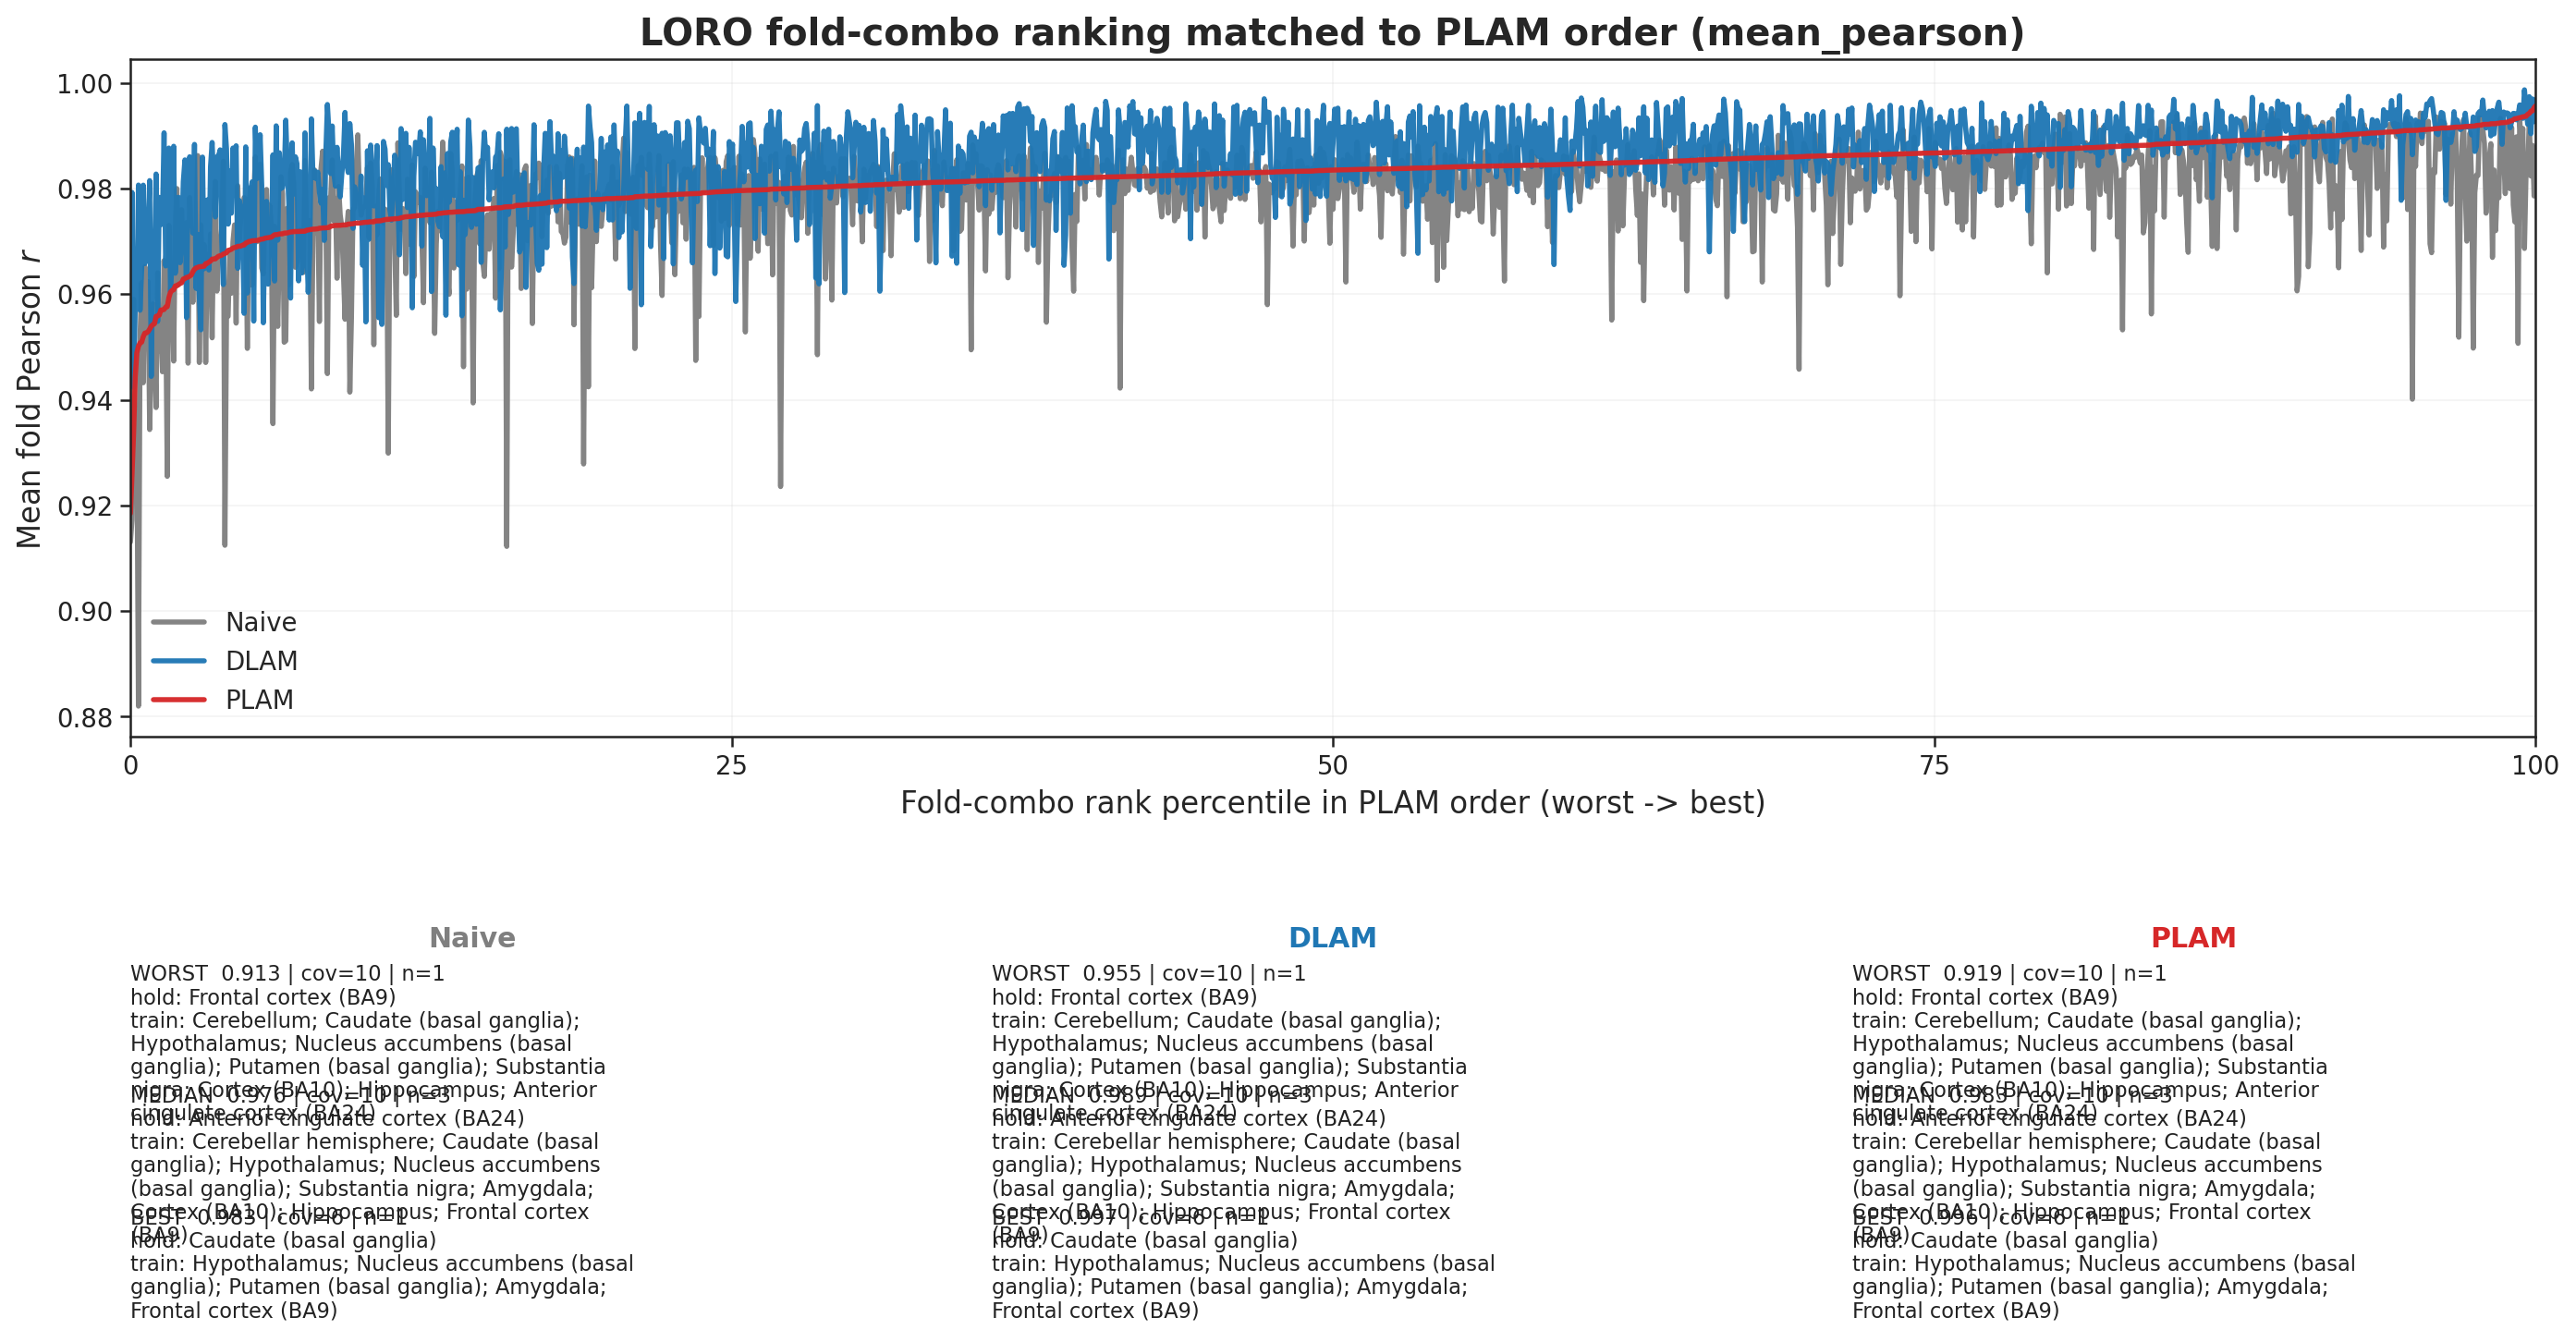

In [17]:
fig, axes, independent_split_df = plot_fold_combo_ranked_overlay(
    combo_df,
    PREPOST,
    models=MODELS,
    metric=FOLD_COMBO_METRIC,
    points_style=FOLD_COMBO_POINTS_STYLE,
)
display(independent_split_df)

fig, axes, matched_split_df, matched_combo_df = plot_fold_combo_matched_overlay(
    combo_df,
    PREPOST,
    models=MODELS,
    reference_model=FOLD_COMBO_REFERENCE_MODEL,
    metric=FOLD_COMBO_METRIC,
    show_points=False,
)
display(matched_split_df)


### Fold-Difficulty Decomposition

Per-fold cross-subject mean vs std. Splits structurally-hard folds (low mean, low std) from subject-mixing failures (low mean, high std). Singletons and `n<5` fold-combos are excluded — std on n<5 is sampling noise. Marker area scales with `n_subjects` so visual weight tracks evidence.


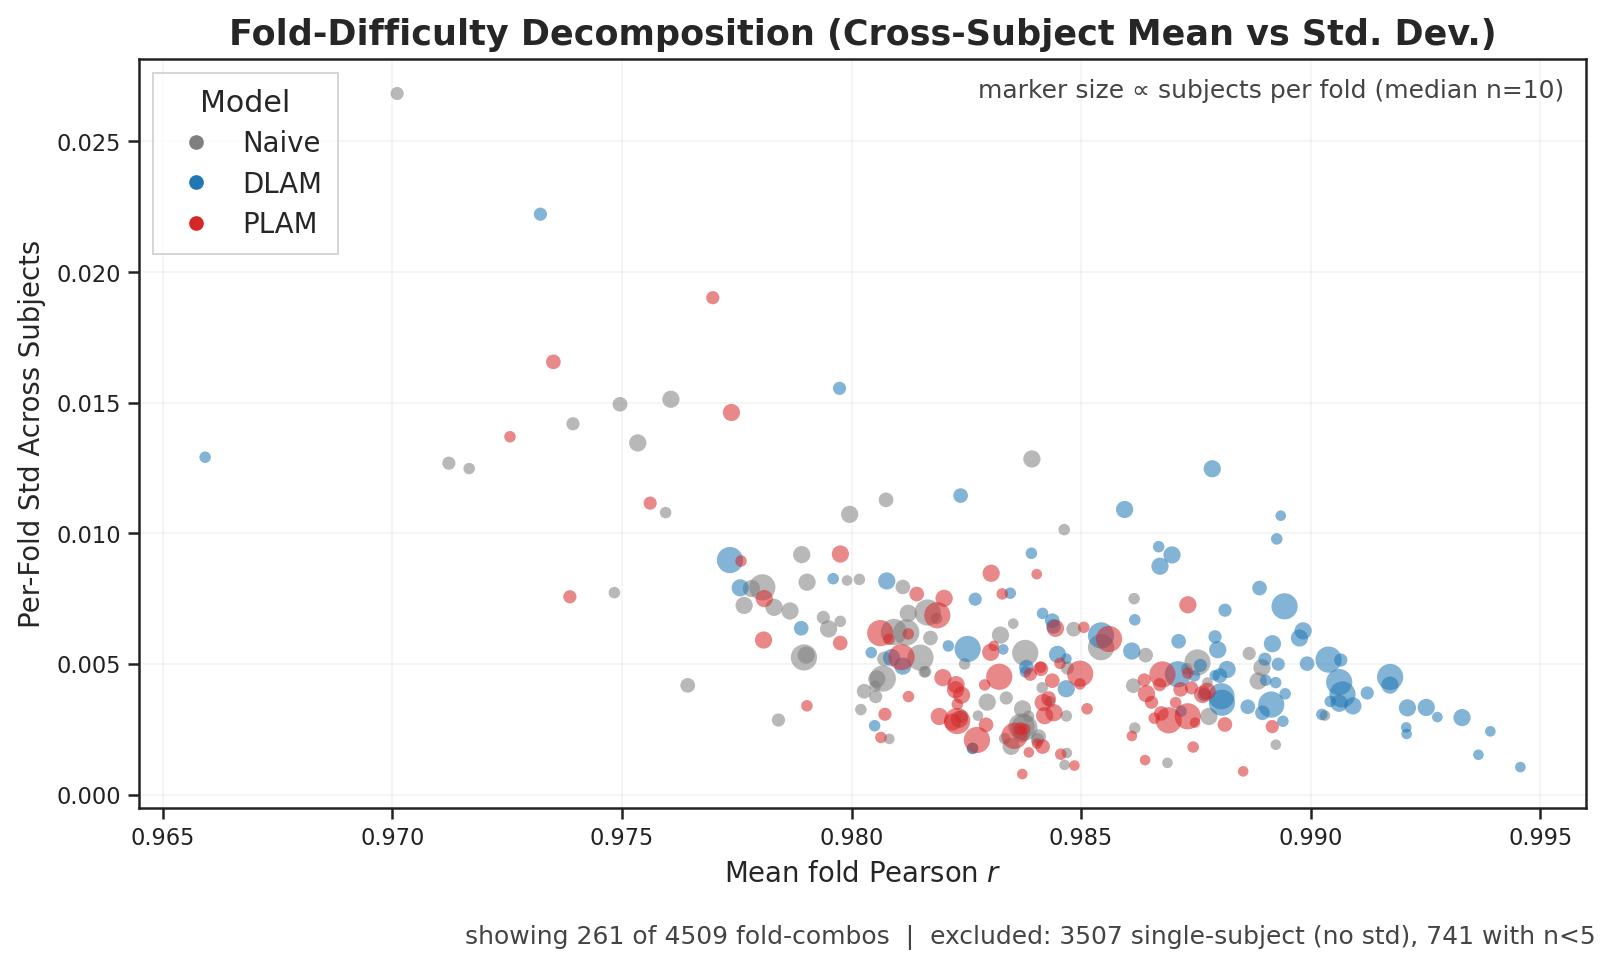

In [18]:
fig, ax = plot_fold_std_vs_mean(
    combo_df,
    metric=FOLD_COMBO_METRIC,
    min_subjects=5,
)


## Distance to Training vs Performance

Each LORO fold split is a point: x = distance from the held-out region to the (centroid of the)
training set, y = fold metric. A quantile-binned mean ± SEM line is overlaid per model
(up to `DISTANCE_N_BINS` bins).


,model,_bin,x_center,mean,sem,n
0,dlam,0,13.586970,0.982888,0.000522,196
1,dlam,1,14.623222,0.981146,0.000896,71
2,dlam,2,16.055634,0.989475,0.000394,214
3,dlam,3,17.542344,0.983430,0.000661,72
4,dlam,4,18.723823,0.986705,0.000536,90


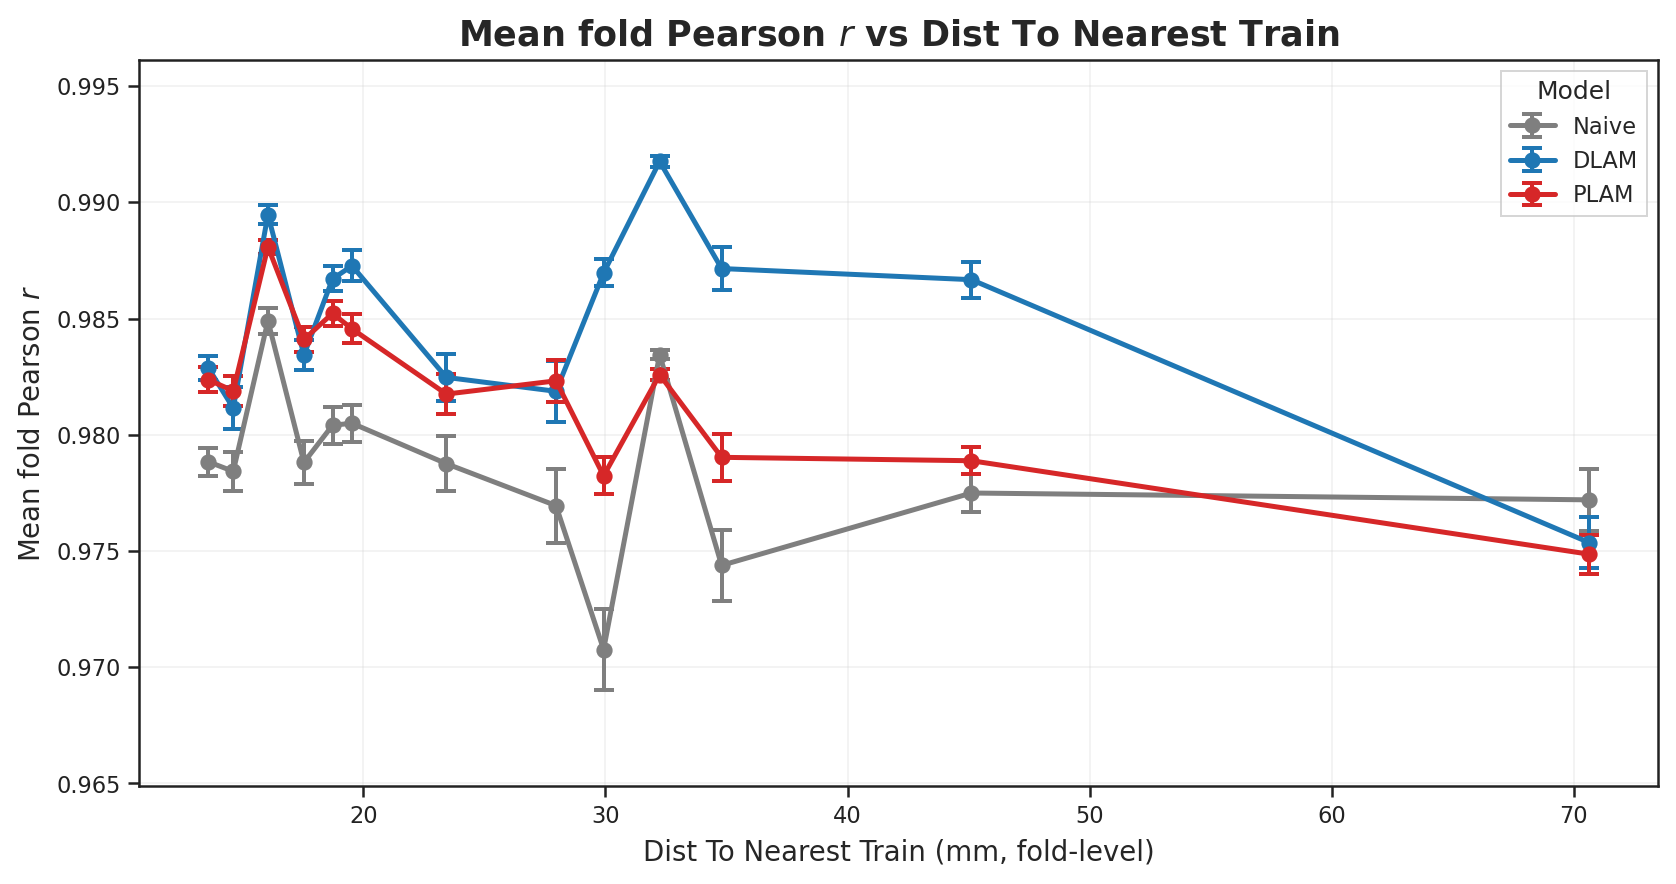

In [19]:
fig, ax, distance_bin_df = plot_distance_to_train_vs_metric(
    combo_df,
    metric=FOLD_COMBO_METRIC,
    distance_col=DISTANCE_COL,
    n_bins=DISTANCE_N_BINS,
)
display(distance_bin_df.head())
